<h1><img src="../../../icons/tk_full_logo.svg" width="80" /> AI Lab Education</h1>

# 🔍 Build a RAG Pipeline: Your AI Research Assistant

Welcome to the **most exciting part** of the AI Research Lab series! You've validated your platform (notebook 00) and configured your models (notebook 01). Now it's time to build a **real-world RAG (Retrieval-Augmented Generation)** system that can search academic papers and answer questions like an expert researcher.

## 🎯 What You'll Learn

In this notebook, you'll:
- ✅ **Fetch research papers** from ArXiv using their API
- ✅ **Chunk documents** for semantic search using LangChain
- ✅ **Generate embeddings** using your local embedding model via LiteLLM
- ✅ **Store vectors** in Qdrant for blazing-fast similarity search
- ✅ **Build a RAG chain** that retrieves context and generates answers
- ✅ **Trace everything** with Langfuse for debugging and optimization

## 💡 Why RAG is a Game-Changer

Traditional LLMs have limitations:
- ❌ **Knowledge cutoff** - They don't know about papers published after training
- ❌ **Hallucinations** - They make up plausible-sounding but false information
- ❌ **No sources** - Can't cite where information comes from

**RAG solves this** by:
- ✅ **Grounding answers in real documents** - Retrieves actual paper content
- ✅ **Always up-to-date** - Just add new papers to your vector database
- ✅ **Explainable** - Shows exactly which papers were used
- ✅ **Trustworthy** - Can verify every claim against source material

## 🏗️ The RAG Pipeline Architecture

```mermaid
graph TB
    A[📄 ArXiv Papers] --> B[✂️ Chunk Documents]
    B --> C[🧮 Generate Embeddings<br/>via LiteLLM]
    C --> D[💾 Store in Qdrant<br/>Vector Database]
    
    E[❓ User Question] --> F[🧮 Embed Question<br/>via LiteLLM]
    F --> G[🔍 Search Qdrant<br/>Find Similar Chunks]
    G --> H[📚 Retrieve Top 5 Chunks]
    H --> I[🤖 LLM Generates Answer<br/>using Retrieved Context]
    I --> J[✨ Answer with Sources]
    
    D -.->|Similarity Search| G
    
    K[📊 Langfuse] -.->|Observability| I
    
    style A fill:#e1f5ff
    style E fill:#e1f5ff
    style D fill:#e8f5e9
    style I fill:#fff4e6
    style J fill:#c8e6c9
    style K fill:#fce4ec
```

### 🔄 How RAG Works Step-by-Step

**Indexing Phase** (Steps 1-4):
1. **Fetch papers** → Download research papers from ArXiv on "LoRA fine-tuning"
2. **Chunk** → Split each paper into ~1000 character chunks with overlap
3. **Embed** → Convert each chunk into a 768-dimensional vector using `nomic-embed`
4. **Store** → Save vectors + metadata (title, authors, etc.) in Qdrant

**Query Phase** (Steps 5-7):
5. **User asks**: *"What is LoRA and how does it work?"*
6. **Embed question** → Convert question to same 768-dim vector space
7. **Retrieve** → Find 5 most similar chunks from Qdrant (cosine similarity)
8. **Generate** → LLM reads the chunks and generates a grounded answer
9. **Cite** → Show which papers were used as sources

---

**Prerequisites**: 
- ✅ Completed `00-platform-validation.ipynb`
- ✅ Completed `01-register-litellm.ipynb` (models registered)
- ✅ LiteLLM has `gpt-oss` (chat) and `nomic-embed` (embeddings) configured

Let's build your AI research assistant!

---
## Setup

**What**: Initialize helper functions and load platform service credentials from environment variables.

**Why**: We need to connect to 7 Thinkube platform services:
- **LiteLLM** - Routes to local LLM (gpt-oss) and embeddings (nomic-embed)
- **Qdrant** - Vector database for fast similarity search
- **Langfuse** - Observability and tracing for debugging

**How**: Load credentials from environment variables injected by JupyterHub, then create helper functions for colored output.

In [15]:
import os
from IPython.display import display, HTML

# Helper functions for colored output
def success(msg):
    display(HTML(f'<span style="color: #00c896; font-weight: bold;">✅ {msg}</span>'))

def info(msg):
    display(HTML(f'<span style="color: #3498db;">ℹ️  {msg}</span>'))

def error(msg):
    display(HTML(f'<span style="color: #e74c3c; font-weight: bold;">❌ {msg}</span>'))

# Platform services
LITELLM_ENDPOINT = os.environ.get('LITELLM_ENDPOINT')
LITELLM_KEY = os.environ.get('LITELLM_MASTER_KEY')
QDRANT_URL = os.environ.get('QDRANT_URL')
LANGFUSE_HOST = os.environ.get('LANGFUSE_HOST')
LANGFUSE_PUBLIC_KEY = os.environ.get('LANGFUSE_PUBLIC_KEY')
LANGFUSE_SECRET_KEY = os.environ.get('LANGFUSE_SECRET_KEY')

info(f"LiteLLM endpoint: {LITELLM_ENDPOINT}")
info(f"Qdrant URL: {QDRANT_URL}")
info(f"Langfuse host: {LANGFUSE_HOST}")

---
## 1. Fetch Papers from ArXiv

**What**: Download academic papers from ArXiv using their free public API.

**Why**: 
- **Real knowledge base** - We need actual research papers to demonstrate RAG
- **Domain expertise** - Papers on "LoRA fine-tuning" match our AI research theme
- **Rich content** - Abstracts contain technical details perfect for Q&A

**How**: Use the `arxiv` Python package to search for 20 papers matching our query. We fetch metadata (title, authors, publication date) and abstracts as our text corpus.

**Educational Note**: In production, you'd download full PDF text using ArXiv's bulk download or PDF parsing. For this tutorial, abstracts provide enough content to demonstrate RAG capabilities.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# Load cached data (skip if you want fresh ArXiv fetch)
# ═══════════════════════════════════════════════════════════════════════════════
# Run this cell to load previously cached papers, chunks, and embeddings.
# This skips the slow ArXiv fetch and LaTeX download (~10+ minutes).
# If cache files don't exist, this cell does nothing - proceed to next cell.

import pickle
import os

PAPERS_CACHE = "papers_cache.pkl"
CHUNKS_CACHE = "chunks_cache.pkl"
EMBEDDINGS_CACHE = "embeddings_cache.pkl"

# Check if cache exists
if os.path.exists(PAPERS_CACHE):
    with open(PAPERS_CACHE, 'rb') as f:
        papers = pickle.load(f)
    success(f"Loaded {len(papers)} papers from cache")
    
    # Count by category
    adalora_count = len([p for p in papers if p.get('category') == 'adalora'])
    fixed_count = len([p for p in papers if p.get('category') == 'fixed'])
    general_count = len([p for p in papers if p.get('category') == 'general'])
    papers_with_latex = len([p for p in papers if p.get('latex_source')])
    
    info(f"  - AdaLoRA papers: {adalora_count}")
    info(f"  - Fixed-rank papers: {fixed_count}")
    info(f"  - General LoRA papers: {general_count}")
    info(f"  - Papers with LaTeX source: {papers_with_latex}")
    
    # Load chunks if available
    if os.path.exists(CHUNKS_CACHE):
        with open(CHUNKS_CACHE, 'rb') as f:
            chunks = pickle.load(f)
        success(f"Loaded {len(chunks)} chunks from cache")
        info("  → Skip cell 2 (chunking) and go to cell 3 (embeddings) or cell 4 (Qdrant)")
    
    # Load embeddings if available
    if os.path.exists(EMBEDDINGS_CACHE):
        with open(EMBEDDINGS_CACHE, 'rb') as f:
            embeddings = pickle.load(f)
        success(f"Loaded {len(embeddings)} embeddings from cache")
        info("  → Skip to cell 4 (Store in Qdrant)")
    
    info("\n💡 TIP: If you have all 3 caches, skip directly to cell 4 (Store in Qdrant)")
else:
    info("No cache found - run the next cell to fetch papers from ArXiv")
    info("(This will take ~10+ minutes due to ArXiv rate limiting)")

In [17]:
import arxiv
import time
import tarfile
import io
import re
import requests
import os

# ═══════════════════════════════════════════════════════════════════════════════
# Fetch papers from ArXiv with BALANCED queries for AdaLoRA vs Fixed-Rank debate
# ═══════════════════════════════════════════════════════════════════════════════
info("Fetching papers from ArXiv with balanced coverage for debate...")

# Query 1: AdaLoRA and adaptive rank methods (Pro-AdaLoRA evidence)
query_adalora = '"AdaLoRA" OR "adaptive rank" OR "rank allocation" OR "dynamic rank" OR "importance-aware LoRA" OR "layer-wise rank"'

# Query 2: Fixed-rank LoRA advantages (Pro-FixedRank evidence)
query_fixed = '"LoRA" AND ("fixed rank" OR "simplicity" OR "stable training" OR "hyperparameter tuning" OR "rank selection")'

# Query 3: General LoRA papers (background knowledge)
query_lora_general = '"LoRA" OR "low-rank adaptation" OR "parameter-efficient fine-tuning"'

client = arxiv.Client()
papers = []

# ═══════════════════════════════════════════════════════════════════════════════
# LaTeX Cache Configuration
# ═══════════════════════════════════════════════════════════════════════════════
# Cache raw LaTeX files locally to avoid re-downloading from ArXiv during debugging.
# This significantly speeds up iteration when modifying the LaTeX processing logic.

LATEX_CACHE_DIR = "latex_cache"
os.makedirs(LATEX_CACHE_DIR, exist_ok=True)
info(f"LaTeX cache directory: {LATEX_CACHE_DIR}/")

def get_latex_cache_path(paper_id):
    """Get the cache file path for a paper's LaTeX source."""
    # Clean paper_id (remove version suffix like v1, v2)
    clean_id = paper_id.split('v')[0] if 'v' in paper_id else paper_id
    return os.path.join(LATEX_CACHE_DIR, f"{clean_id}.tex")

def load_latex_from_cache(paper_id):
    """Load LaTeX source from local cache if available."""
    cache_path = get_latex_cache_path(paper_id)
    if os.path.exists(cache_path):
        with open(cache_path, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read()
    return None

def save_latex_to_cache(paper_id, tex_content):
    """Save LaTeX source to local cache for future runs."""
    if tex_content:
        cache_path = get_latex_cache_path(paper_id)
        with open(cache_path, 'w', encoding='utf-8', errors='ignore') as f:
            f.write(tex_content)

# ═══════════════════════════════════════════════════════════════════════════════
# Helper functions for LaTeX source extraction
# ═══════════════════════════════════════════════════════════════════════════════

def download_latex_source(paper_id):
    """Download and extract LaTeX source from ArXiv (with local caching)."""
    # Check cache first
    cached = load_latex_from_cache(paper_id)
    if cached:
        return cached
    
    # Clean paper_id (remove version suffix like v1, v2)
    clean_id = paper_id.split('v')[0] if 'v' in paper_id else paper_id
    url = f"https://arxiv.org/e-print/{clean_id}"
    
    try:
        response = requests.get(url, timeout=30, headers={'User-Agent': 'Thinkube-Research-Assistant/1.0'})
        if response.status_code != 200:
            return None
        
        # Try to extract .tex files from tar.gz
        tex_content = None
        try:
            tar = tarfile.open(fileobj=io.BytesIO(response.content), mode='r:gz')
            tex_files = []
            for member in tar.getmembers():
                if member.name.endswith('.tex'):
                    f = tar.extractfile(member)
                    if f:
                        tex_files.append(f.read().decode('utf-8', errors='ignore'))
            tex_content = '\n'.join(tex_files) if tex_files else None
        except tarfile.TarError:
            # Single file (not tar.gz) - try direct decode
            try:
                tex_content = response.content.decode('utf-8', errors='ignore')
            except:
                tex_content = None
        
        # Save to cache for future runs
        if tex_content:
            save_latex_to_cache(paper_id, tex_content)
        
        return tex_content
    except Exception as e:
        return None

def latex_to_plain(text):
    """Convert LaTeX to readable plain text for better embeddings.
    
    LaTeX content has poor semantic similarity with natural language queries
    because embeddings don't understand LaTeX syntax. Converting to plain text
    dramatically improves retrieval quality for results tables and algorithms.
    """
    if not text:
        return text
    
    # Remove LaTeX formatting commands
    text = re.sub(r'\\textbf\{([^}]*)\}', r'\1', text)
    text = re.sub(r'\\textit\{([^}]*)\}', r'\1', text)
    text = re.sub(r'\\emph\{([^}]*)\}', r'\1', text)
    text = re.sub(r'\\underline\{([^}]*)\}', r'\1', text)
    text = re.sub(r'\\makecell\{([^}]*)\}', r'\1', text)
    text = re.sub(r'\\multirow\{[^}]*\}\{[^}]*\}\{([^}]*)\}', r'\1', text)
    text = re.sub(r'\\multicolumn\{[^}]*\}\{[^}]*\}\{([^}]*)\}', r'\1', text)
    
    # Remove citations and references
    text = re.sub(r'\\cite\{[^}]*\}', '', text)
    text = re.sub(r'\\ref\{[^}]*\}', '', text)
    text = re.sub(r'\\label\{[^}]*\}', '', text)
    
    # Remove table structure commands
    text = re.sub(r'\\toprule|\\midrule|\\bottomrule|\\hline|\\cline\{[^}]*\}', '', text)
    text = re.sub(r'\\begin\{tabular\}\{[^}]*\}', '', text)
    text = re.sub(r'\\end\{tabular\}', '', text)
    
    # Convert table delimiters to readable format
    text = text.replace('&', ' | ')
    text = text.replace('\\\\', '\n')
    
    # Remove other common LaTeX commands
    text = re.sub(r'\\[a-zA-Z]+\*?\{([^}]*)\}', r'\1', text)  # Generic \command{text} → text
    text = re.sub(r'\\[a-zA-Z]+\*?', '', text)  # Remove standalone commands
    
    # Clean up whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\n\s*\n', '\n\n', text)  # Normalize paragraph breaks
    
    return text

def extract_algorithms(tex_content):
    """Extract algorithm environments from LaTeX."""
    if not tex_content:
        return []
    
    patterns = [
        r'\\begin\{algorithm\}(.*?)\\end\{algorithm\}',
        r'\\begin\{algorithm\*\}(.*?)\\end\{algorithm\*\}',
        r'\\begin\{algorithmic\}(.*?)\\end\{algorithmic\}',
        r'\\begin\{lstlisting\}(.*?)\\end\{lstlisting\}',
        r'\\begin\{minted\}.*?\}(.*?)\\end\{minted\}',
    ]
    algorithms = []
    for pattern in patterns:
        matches = re.findall(pattern, tex_content, re.DOTALL | re.IGNORECASE)
        algorithms.extend(matches)
    return algorithms

def extract_tables(tex_content):
    """Extract tables with results (likely contain performance metrics)."""
    if not tex_content:
        return []
    
    patterns = [
        r'\\begin\{table\}(.*?)\\end\{table\}',
        r'\\begin\{table\*\}(.*?)\\end\{table\*\}',
        r'\\begin\{tabular\}(.*?)\\end\{tabular\}',
    ]
    tables = []
    for pattern in patterns:
        matches = re.findall(pattern, tex_content, re.DOTALL | re.IGNORECASE)
        tables.extend(matches)
    return tables

def extract_equations(tex_content):
    """Extract key equations (LoRA's W = W0 + BA, etc.)."""
    if not tex_content:
        return []
    
    patterns = [
        r'\\begin\{equation\}(.*?)\\end\{equation\}',
        r'\\begin\{equation\*\}(.*?)\\end\{equation\*\}',
        r'\\begin\{align\}(.*?)\\end\{align\}',
        r'\\begin\{align\*\}(.*?)\\end\{align\*\}',
    ]
    equations = []
    for pattern in patterns:
        matches = re.findall(pattern, tex_content, re.DOTALL | re.IGNORECASE)
        equations.extend(matches)
    return equations

# ═══════════════════════════════════════════════════════════════════════════════
# Fetch AdaLoRA papers (Pro-AdaLoRA evidence)
# ═══════════════════════════════════════════════════════════════════════════════
info("Fetching AdaLoRA/adaptive rank papers (Pro-AdaLoRA evidence)...")
search_adalora = arxiv.Search(
    query=query_adalora,
    max_results=50,
    sort_by=arxiv.SortCriterion.Relevance
)

for i, result in enumerate(client.results(search_adalora)):
    papers.append({
        'paper_id': result.entry_id.split('/')[-1],
        'title': result.title,
        'authors': ', '.join([a.name for a in result.authors]),
        'published': result.published.strftime('%Y-%m-%d'),
        'summary': result.summary,
        'full_text': f"Title: {result.title}\n\nAbstract: {result.summary}",
        'category': 'adalora'
    })
    if (i + 1) % 10 == 0:
        info(f"  Fetched {i + 1} AdaLoRA papers...")

adalora_count = len([p for p in papers if p['category'] == 'adalora'])
info(f"Fetched {adalora_count} AdaLoRA papers")

# ═══════════════════════════════════════════════════════════════════════════════
# Fetch Fixed-rank LoRA papers (Pro-FixedRank evidence)
# ═══════════════════════════════════════════════════════════════════════════════
info("Fetching fixed-rank LoRA papers (Pro-FixedRank evidence)...")
search_fixed = arxiv.Search(
    query=query_fixed,
    max_results=50,
    sort_by=arxiv.SortCriterion.Relevance
)

for i, result in enumerate(client.results(search_fixed)):
    paper_id = result.entry_id.split('/')[-1]
    # Avoid duplicates
    if not any(p['paper_id'] == paper_id for p in papers):
        papers.append({
            'paper_id': paper_id,
            'title': result.title,
            'authors': ', '.join([a.name for a in result.authors]),
            'published': result.published.strftime('%Y-%m-%d'),
            'summary': result.summary,
            'full_text': f"Title: {result.title}\n\nAbstract: {result.summary}",
            'category': 'fixed'
        })
    if (i + 1) % 10 == 0:
        info(f"  Processed {i + 1} fixed-rank papers...")

fixed_count = len([p for p in papers if p['category'] == 'fixed'])
info(f"Fetched {fixed_count} fixed-rank papers (after deduplication)")

# ═══════════════════════════════════════════════════════════════════════════════
# Fetch general LoRA papers (background knowledge)
# ═══════════════════════════════════════════════════════════════════════════════
info("Fetching general LoRA papers (background knowledge)...")
search_general = arxiv.Search(
    query=query_lora_general,
    max_results=50,
    sort_by=arxiv.SortCriterion.Relevance
)

for i, result in enumerate(client.results(search_general)):
    paper_id = result.entry_id.split('/')[-1]
    if not any(p['paper_id'] == paper_id for p in papers):
        papers.append({
            'paper_id': paper_id,
            'title': result.title,
            'authors': ', '.join([a.name for a in result.authors]),
            'published': result.published.strftime('%Y-%m-%d'),
            'summary': result.summary,
            'full_text': f"Title: {result.title}\n\nAbstract: {result.summary}",
            'category': 'general'
        })
    if (i + 1) % 10 == 0:
        info(f"  Processed {i + 1} general papers...")

general_count = len([p for p in papers if p['category'] == 'general'])
info(f"Fetched {general_count} general LoRA papers (after deduplication)")

# ═══════════════════════════════════════════════════════════════════════════════
# Download LaTeX source for algorithm extraction (with caching)
# ═══════════════════════════════════════════════════════════════════════════════
info("Downloading LaTeX source for algorithm extraction...")
info("(Using local cache - subsequent runs will be much faster)")

papers_with_latex = 0
papers_from_cache = 0
total_algorithms = 0
total_tables = 0
total_equations = 0

for i, paper in enumerate(papers):
    # Check if already cached
    cache_path = get_latex_cache_path(paper['paper_id'])
    from_cache = os.path.exists(cache_path)
    
    tex_content = download_latex_source(paper['paper_id'])
    if tex_content:
        paper['latex_source'] = tex_content
        paper['algorithms'] = extract_algorithms(tex_content)
        paper['tables'] = extract_tables(tex_content)
        paper['equations'] = extract_equations(tex_content)
        papers_with_latex += 1
        if from_cache:
            papers_from_cache += 1
        total_algorithms += len(paper['algorithms'])
        total_tables += len(paper['tables'])
        total_equations += len(paper['equations'])
    else:
        paper['latex_source'] = None
        paper['algorithms'] = []
        paper['tables'] = []
        paper['equations'] = []
    
    if (i + 1) % 20 == 0:
        info(f"  Processed {i + 1}/{len(papers)} papers for LaTeX...")
    
    # Rate limit per ArXiv API Terms of Use (no more than 1 request per 3 seconds)
    # Skip delay if loaded from cache
    if not from_cache:
        time.sleep(3)

success(f"Total: {len(papers)} papers from ArXiv")
info(f"  - AdaLoRA papers: {adalora_count}")
info(f"  - Fixed-rank papers: {fixed_count}")
info(f"  - General LoRA papers: {general_count}")
info(f"  - Papers with LaTeX source: {papers_with_latex} ({papers_from_cache} from cache)")
info(f"  - Total algorithms extracted: {total_algorithms}")
info(f"  - Total tables extracted: {total_tables}")
info(f"  - Total equations extracted: {total_equations}")

total_chars = sum(len(p['full_text']) for p in papers)
info(f"Total abstract content: {total_chars:,} characters ({total_chars/1000:.1f}K)")

# ArXiv attribution (required by Terms of Use)
print("\n📜 Thank you to arXiv for use of its open access interoperability.")


📜 Thank you to arXiv for use of its open access interoperability.


---
## 2. Chunk Documents

**What**: Split papers into smaller, overlapping chunks of ~1000 characters each.

**Why**: 
- **Context window limits** - LLMs can only process so much text at once (typically 4K-32K tokens)
- **Precision retrieval** - Finding a relevant paragraph is better than retrieving an entire paper
- **Better embeddings** - Focused chunks create more meaningful semantic vectors
- **Overlap preserves context** - 200-character overlap ensures sentences aren't cut mid-thought

**How**: LangChain's `RecursiveCharacterTextSplitter` intelligently splits text by trying separators in order:
1. Double newlines (`\n\n`) - Paragraph boundaries
2. Single newlines (`\n`) - Line breaks
3. Spaces (` `) - Word boundaries
4. Characters - Last resort

This creates 40-50 chunks from our 20 papers, giving us a rich knowledge base for semantic search.

In [18]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

info("Chunking documents with LangChain...")
info("Creating chunks with content_type metadata for targeted retrieval...")
info("Converting LaTeX to plain text for better embeddings...")

# Create text splitter for chunking documents
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", " ", ""]
)

chunks = []

for paper in papers:
    # ═══════════════════════════════════════════════════════════════════════════
    # Abstract chunks (content_type: 'abstract')
    # Abstracts are already in natural language, no conversion needed
    # ═══════════════════════════════════════════════════════════════════════════
    splits = text_splitter.split_text(paper['full_text'])
    
    for i, chunk_text in enumerate(splits):
        chunks.append({
            'paper_id': paper['paper_id'],
            'title': paper['title'],
            'chunk_index': i,
            'text': chunk_text,           # Plain text (for embeddings)
            'text_raw': chunk_text,       # Raw text (same as text for abstracts)
            'published_date': paper['published'],
            'authors': paper['authors'],
            'content_type': 'abstract',
            'category': paper.get('category', 'general')
        })
    
    # ═══════════════════════════════════════════════════════════════════════════
    # Algorithm chunks (content_type: 'algorithm')
    # These contain actual pseudocode/algorithm descriptions from papers
    # Store both raw LaTeX and plain text version for better retrieval
    # ═══════════════════════════════════════════════════════════════════════════
    for j, algo in enumerate(paper.get('algorithms', [])):
        # Raw LaTeX version
        algo_text_raw = f"Algorithm from paper '{paper['title']}':\n\n{algo}"
        # Plain text version for embeddings
        algo_text_plain = f"Algorithm from paper '{paper['title']}':\n\n{latex_to_plain(algo)}"
        
        # Split long algorithms if needed (use plain text for splitting)
        algo_splits_plain = text_splitter.split_text(algo_text_plain)
        algo_splits_raw = text_splitter.split_text(algo_text_raw)
        
        # Pair up plain and raw chunks (may have different counts due to size differences)
        for k, algo_chunk_plain in enumerate(algo_splits_plain):
            # Get corresponding raw chunk if available, otherwise use plain
            algo_chunk_raw = algo_splits_raw[k] if k < len(algo_splits_raw) else algo_chunk_plain
            
            chunks.append({
                'paper_id': paper['paper_id'],
                'title': paper['title'],
                'chunk_index': f"algo-{j}-{k}",
                'text': algo_chunk_plain,     # Plain text (for embeddings)
                'text_raw': algo_chunk_raw,   # Raw LaTeX (for display/code gen)
                'published_date': paper['published'],
                'authors': paper['authors'],
                'content_type': 'algorithm',
                'category': paper.get('category', 'general')
            })
    
    # ═══════════════════════════════════════════════════════════════════════════
    # Results table chunks (content_type: 'results')
    # These contain performance metrics, comparisons, benchmarks
    # CRITICAL: Convert LaTeX to plain text for better embedding retrieval
    # ═══════════════════════════════════════════════════════════════════════════
    for j, table in enumerate(paper.get('tables', [])):
        # Raw LaTeX version
        table_text_raw = f"Results table from paper '{paper['title']}':\n\n{table}"
        # Plain text version for embeddings (converts \textbf{}, &, \\ etc.)
        table_text_plain = f"Results table from paper '{paper['title']}':\n\n{latex_to_plain(table)}"
        
        # Split long tables if needed
        table_splits_plain = text_splitter.split_text(table_text_plain)
        table_splits_raw = text_splitter.split_text(table_text_raw)
        
        for k, table_chunk_plain in enumerate(table_splits_plain):
            table_chunk_raw = table_splits_raw[k] if k < len(table_splits_raw) else table_chunk_plain
            
            chunks.append({
                'paper_id': paper['paper_id'],
                'title': paper['title'],
                'chunk_index': f"table-{j}-{k}",
                'text': table_chunk_plain,    # Plain text (for embeddings)
                'text_raw': table_chunk_raw,  # Raw LaTeX (for display)
                'published_date': paper['published'],
                'authors': paper['authors'],
                'content_type': 'results',
                'category': paper.get('category', 'general')
            })
    
    # ═══════════════════════════════════════════════════════════════════════════
    # Equation chunks (content_type: 'equation')
    # Key mathematical formulations (e.g., W = W0 + BA for LoRA)
    # Keep raw LaTeX for equations since math notation is meaningful
    # ═══════════════════════════════════════════════════════════════════════════
    for j, equation in enumerate(paper.get('equations', [])):
        eq_text_raw = f"Key equation from paper '{paper['title']}':\n\n{equation}"
        eq_text_plain = f"Key equation from paper '{paper['title']}':\n\n{latex_to_plain(equation)}"
        
        chunks.append({
            'paper_id': paper['paper_id'],
            'title': paper['title'],
            'chunk_index': f"eq-{j}",
            'text': eq_text_plain,      # Plain text (for embeddings)
            'text_raw': eq_text_raw,    # Raw LaTeX (for display)
            'published_date': paper['published'],
            'authors': paper['authors'],
            'content_type': 'equation',
            'category': paper.get('category', 'general')
        })

# Count chunks by type
abstract_chunks = len([c for c in chunks if c['content_type'] == 'abstract'])
algorithm_chunks = len([c for c in chunks if c['content_type'] == 'algorithm'])
results_chunks = len([c for c in chunks if c['content_type'] == 'results'])
equation_chunks = len([c for c in chunks if c['content_type'] == 'equation'])

success(f"Created {len(chunks)} total chunks from {len(papers)} papers")
info(f"  - Abstract chunks: {abstract_chunks}")
info(f"  - Algorithm chunks: {algorithm_chunks}")
info(f"  - Results table chunks: {results_chunks}")
info(f"  - Equation chunks: {equation_chunks}")
info(f"Average chunks per paper: {len(chunks) / len(papers):.1f}")
info("")
info("💡 Each chunk now has 'text' (plain) and 'text_raw' (LaTeX) fields")
info("   - 'text' is used for embedding generation (better retrieval)")
info("   - 'text_raw' is stored in Qdrant for display and code generation")

In [19]:
import pickle

# Save current papers to cache file
CACHE_FILE = "papers_cache.pkl"
with open(CACHE_FILE, 'wb') as f:
    pickle.dump(papers, f)
print(f"✅ Saved {len(papers)} papers to {CACHE_FILE}")

# Also save chunks if they exist
try:
    with open("chunks_cache.pkl", 'wb') as f:
        pickle.dump(chunks, f)
    print(f"✅ Saved {len(chunks)} chunks to chunks_cache.pkl")
except NameError:
    print("ℹ️ No chunks variable found (not yet created)")

# Save embeddings if they exist
try:
    with open("embeddings_cache.pkl", 'wb') as f:
        pickle.dump(embeddings, f)
    print(f"✅ Saved {len(embeddings)} embeddings to embeddings_cache.pkl")
except NameError:
    print("ℹ️ No embeddings variable found (not yet created)")

✅ Saved 142 papers to papers_cache.pkl
✅ Saved 8475 chunks to chunks_cache.pkl
✅ Saved 10975 embeddings to embeddings_cache.pkl


---
## 3. Generate Embeddings

**What**: Convert each text chunk into a 768-dimensional numerical vector using the `nomic-embed-text-v1.5` model.

**Why**: 
- **Semantic understanding** - Embeddings capture meaning, not just keywords
- **Similarity search** - Similar meaning → similar vectors → findable with cosine similarity
- **Mathematical operations** - Vectors enable distance calculations, clustering, and search algorithms
- **Language-agnostic** - Works across languages and technical jargon

**How**: 
1. Use OpenAI-compatible client pointing to **LiteLLM** (routes to local embedding model)
2. Call `nomic-embed` model for each chunk → get 768-dimensional vector
3. Track the operation with **Langfuse spans** for observability
4. Store embeddings for upload to Qdrant

**Key Insight**: The embedding model was trained to place semantically similar text close together in 768-dimensional space. When a user asks "What is LoRA?", we embed their question and find the closest chunk vectors - those chunks likely contain the answer!

**Performance Note**: We generate ~40-50 embeddings. In production with millions of documents, you'd batch this process and use GPU acceleration.

In [6]:
from openai import OpenAI
from langfuse import get_client

# Initialize OpenAI client pointing to LiteLLM
client = OpenAI(
    base_url=LITELLM_ENDPOINT,
    api_key=LITELLM_KEY
)

# Initialize Langfuse client (SDK v3 API)
langfuse = get_client()

info(f"Generating embeddings for {len(chunks)} chunks with Langfuse tracing...")
info("Using plain text (LaTeX converted) for embedding generation")

# Create a parent span for the entire embedding generation process (SDK v3)
embedding_span = langfuse.start_span(name="embedding-generation")
embedding_span.update(input={"total_chunks": len(chunks), "model": "nomic-embed"})

embeddings = []
total_tokens = 0

for i, chunk in enumerate(chunks):
    # Create a nested span for each embedding call
    chunk_span = embedding_span.start_span(name=f"embed-chunk-{i}")
    chunk_span.update(input={"text_length": len(chunk['text']), "paper_id": chunk['paper_id']})
    
    # Use 'text' field (plain text) for embedding, NOT 'text_raw' (LaTeX)
    # This dramatically improves retrieval quality for LaTeX-heavy content
    response = client.embeddings.create(
        model="nomic-embed",
        input=chunk['text']  # Plain text version for better embeddings
    )
    embedding = response.data[0].embedding
    embeddings.append(embedding)
    
    # Track token usage if available
    if hasattr(response, 'usage') and response.usage:
        total_tokens += response.usage.total_tokens
    
    # End the chunk span
    chunk_span.update(output={"dimension": len(embedding)})
    chunk_span.end()
    
    if (i + 1) % 100 == 0:
        info(f"  Generated {i + 1}/{len(chunks)} embeddings")

# End the parent span
embedding_span.update(output={
    "total_embeddings": len(embeddings),
    "dimension": len(embeddings[0]),
    "total_tokens": total_tokens
})
embedding_span.end()

# Flush to ensure traces are sent
langfuse.flush()

success(f"All embeddings generated (dimension: {len(embeddings[0])})")
info(f"Total tokens used: {total_tokens:,}")
info(f"Embedding trace sent to Langfuse")

---
## 4. Store in Qdrant

**What**: Upload embeddings + metadata to Qdrant vector database for persistent, fast similarity search.

**Why**: 
- **Lightning-fast search** - Qdrant can search millions of vectors in <100ms using HNSW algorithm
- **Persistent storage** - Vectors survive server restarts, no need to re-embed
- **Rich metadata** - Store paper title, authors, dates, IDs alongside vectors for filtering
- **Production-ready** - Handles real-world scale with horizontal scaling
- **Open source** - Self-hosted on Thinkube platform, no external API costs

**How**: 
1. **Create collection** - Define vector size (768) and distance metric (cosine similarity)
2. **Structure payload** - Each vector gets a unique ID and payload with:
   - `text`: The actual chunk content
   - `metadata`: Paper metadata (title, authors, paper_id, chunk_index)
3. **Batch upload** - Use `upsert()` to insert all vectors at once
4. **Verify** - Check collection has expected point count

**Technical Detail**: We use **cosine similarity** (range: -1 to 1) rather than Euclidean distance because embeddings are normalized. Cosine measures angle between vectors, perfect for semantic similarity.

**Collection Structure**:
```
research_papers/
├── Vector 1: [0.23, -0.45, ...] (768 dims)
│   └── Payload: {text: "...", metadata: {title: "...", ...}}
├── Vector 2: [0.12, 0.89, ...] (768 dims)
│   └── Payload: {text: "...", metadata: {title: "...", ...}}
...
```

In [7]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
import uuid

# Connect to Qdrant with proper HTTPS configuration
info(f"Connecting to Qdrant at {QDRANT_URL}")

qdrant = QdrantClient(
    url=QDRANT_URL,
    port=443,
    https=True,
    verify=False
)

collection_name = "research_papers"

# Create collection (delete if exists to ensure clean state)
try:
    qdrant.delete_collection(collection_name)
    info(f"Deleted existing collection '{collection_name}'")
except:
    pass

qdrant.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(
        size=len(embeddings[0]),
        distance=Distance.COSINE
    )
)

success(f"Created collection '{collection_name}'")

# Prepare points with proper metadata structure including content_type
info(f"Preparing {len(chunks)} vectors for upload...")
info("Including both 'text' (plain) and 'text_raw' (LaTeX) in payload...")

points = []
for chunk, embedding in zip(chunks, embeddings):
    point = PointStruct(
        id=str(uuid.uuid4()),
        vector=embedding,
        payload={
            'text': chunk['text'],              # Plain text (for LangChain retrieval)
            'text_raw': chunk.get('text_raw', chunk['text']),  # Raw LaTeX (for code gen)
            'content_type': chunk.get('content_type', 'abstract'),  # For filtering
            'category': chunk.get('category', 'general'),  # adalora, fixed, general
            'metadata': {
                'paper_id': chunk['paper_id'],
                'title': chunk['title'],
                'chunk_index': chunk['chunk_index'],
                'published_date': chunk['published_date'],
                'authors': chunk['authors'],
                'content_type': chunk.get('content_type', 'abstract'),
                'category': chunk.get('category', 'general')
            }
        }
    )
    points.append(point)

# ═══════════════════════════════════════════════════════════════════════════════
# Batch upsert to avoid Qdrant's 32MB payload size limit
# With ~10K chunks and LaTeX content, total payload can exceed 100MB
# ═══════════════════════════════════════════════════════════════════════════════
BATCH_SIZE = 500
total_batches = (len(points) + BATCH_SIZE - 1) // BATCH_SIZE

info(f"Uploading {len(points)} vectors in {total_batches} batches (batch size: {BATCH_SIZE})...")

for i in range(0, len(points), BATCH_SIZE):
    batch = points[i:i + BATCH_SIZE]
    batch_num = i // BATCH_SIZE + 1
    
    qdrant.upsert(
        collection_name=collection_name,
        points=batch
    )
    
    if batch_num % 5 == 0 or batch_num == total_batches:
        info(f"  Uploaded batch {batch_num}/{total_batches} ({min(i + BATCH_SIZE, len(points))}/{len(points)} points)")

final_count = qdrant.get_collection(collection_name).points_count
success(f"Uploaded {final_count} vectors to Qdrant")

# Show breakdown by content_type
info("Content type distribution in Qdrant:")
for ct in ['abstract', 'algorithm', 'results', 'equation']:
    count = len([c for c in chunks if c.get('content_type') == ct])
    info(f"  - {ct}: {count} chunks")

info("")
info("💡 Payload structure for each vector:")
info("   - 'text': Plain text (used by LangChain retriever, embeddings)")
info("   - 'text_raw': Raw LaTeX (for display, code generation)")
info("   - 'content_type': abstract|algorithm|results|equation (for filtering)")
info("   - 'category': adalora|fixed|general (debate side)")
info("   - 'metadata': paper_id, title, authors, etc.")

---
## 5. Build RAG Chain

**What**: Create a LangChain pipeline that orchestrates retrieval and generation into a complete RAG system.

**Why**: 
- **Retrieval** - Finds relevant context from our vector database (the "R" in RAG)
- **Augmentation** - Injects retrieved context into the LLM prompt (the "A" in RAG)
- **Generation** - LLM synthesizes an answer from the context (the "G" in RAG)
- **Together** - Creates grounded, accurate, source-cited responses

**How**: 
1. **Embed question** → Convert user query to 768-dim vector with `nomic-embed`
2. **Search Qdrant** → Find top 5 most similar chunks (cosine similarity > 0.7 typically)
3. **Build prompt** → Insert chunks as "context" and user question into prompt template
4. **Generate answer** → LLM (gpt-oss) reads context and generates response
5. **Return results** → Answer + source documents with metadata

**The RAG Pipeline Flow**:
```
User: "What is LoRA?"
   ↓
[Embed Query] → [0.45, -0.23, ...] (768-dim vector)
   ↓
[Qdrant Search] → Top 5 chunks about LoRA
   ↓
[Prompt Template] → "Context: <chunks> Question: What is LoRA?"
   ↓
[LLM Generation] → "LoRA (Low-Rank Adaptation) is..."
   ↓
[Return] → {answer: "...", sources: [doc1, doc2, ...]}
```

**Why This Works**: By grounding the LLM in retrieved documents, we eliminate hallucinations and provide verifiable sources. The LLM can't make things up - it must base its answer on the provided context!

---

### ⚠️ Known Issue: Response Truncation

The `gpt-oss` model (GPT-OSS 20B via TensorRT-LLM) sometimes generates an EOS (end-of-sequence) token prematurely, causing responses to truncate mid-sentence. This is a **server-side model issue**, not a client configuration problem.

**Attempted fixes:**
- ✅ Set `max_tokens=8000` (up from default 512) - helps but doesn't fully resolve
- ✅ Simplified prompts to avoid complex formatting
- ✅ Adjusted temperature and request timeout

**Status**: This is a known limitation of the current TensorRT-LLM deployment. For production use, consider:
1. Switching to a different model backend (e.g., vLLM, HuggingFace TGI)
2. Updating the TensorRT-LLM model configuration to fix EOS token generation
3. Implementing retry logic with prompt reformulation

Despite truncation, the RAG pipeline demonstrates full functionality - retrieval, context augmentation, and generation all work correctly.

In [8]:
# Fix LangChain version incompatibility if needed
import subprocess
import sys

try:
    from langchain_openai import OpenAIEmbeddings, ChatOpenAI
    info("LangChain packages already compatible")
except ImportError as e:
    if "ModelProfileRegistry" in str(e):
        info("Fixing LangChain version incompatibility...")
        # Upgrade langchain_core to match langchain_openai requirements
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "langchain_core>=0.3.30"])
        info("Upgraded langchain_core - please restart the kernel and re-run")
    else:
        raise e

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate, SystemMessagePromptTemplate

# Use langchain_community for Qdrant vectorstore (langchain-qdrant not installed)
from langchain_community.vectorstores import Qdrant

info("Building RAG chain...")

# Create LangChain embeddings model
embeddings_model = OpenAIEmbeddings(
    model="nomic-embed",
    openai_api_base=LITELLM_ENDPOINT,
    openai_api_key=LITELLM_KEY
)

# Create Qdrant vector store
vectorstore = Qdrant(
    client=qdrant,
    collection_name=collection_name,
    embeddings=embeddings_model,
    content_payload_key="text",
    metadata_payload_key="metadata"
)

# LLM Configuration
llm = ChatOpenAI(
    model="gpt-oss-20b",
    openai_api_base=LITELLM_ENDPOINT,
    openai_api_key=LITELLM_KEY,
    temperature=0.7,
    max_tokens=8000,
    request_timeout=120
)

system_message = SystemMessagePromptTemplate.from_template(
    """You are a helpful AI research assistant. Provide clear, complete answers based on the research paper context provided."""
)

human_message = HumanMessagePromptTemplate.from_template(
    """Based on the following research paper excerpts, answer the question in 2-3 concise paragraphs.

Context:
{context}

Question: {question}

Answer:"""
)

chat_prompt = ChatPromptTemplate.from_messages([
    system_message,
    human_message
])

# Create RAG chain
rag_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vectorstore.as_retriever(search_kwargs={"k": 5}),
    chain_type_kwargs={"prompt": chat_prompt},
    return_source_documents=True
)

success("RAG chain created successfully")
info("Retriever will fetch top 5 relevant chunks per query")

/tmp/ipykernel_631/2792190997.py:37: LangChainDeprecationWarning: The class `Qdrant` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the `langchain-qdrant package and should be used instead. To use it run `pip install -U `langchain-qdrant` and import as `from `langchain_qdrant import Qdrant``.
  vectorstore = Qdrant(


---
## 6. Add Langfuse Tracing

**What**: Instrument the RAG pipeline with observability using Langfuse.

**Why**: 
- **Debug issues** - See exactly what context was retrieved for each query
- **Measure performance** - Track latency, token usage, and costs
- **Improve quality** - Identify when retrieval fails or answers are poor
- **Production monitoring** - Essential for real-world deployments

**How**: We use Langfuse's **LangChain CallbackHandler** which automatically captures:
- Every LLM call (model, tokens, latency)
- Retrieval operations (what chunks were fetched)
- Chain execution (the full RAG pipeline)

The traces will include `user_id` and `session_id` so you can filter by user or session in the Langfuse dashboard.

**View traces at**: `{LANGFUSE_HOST}` → Traces tab

In [9]:
# Initialize Langfuse for observability
# Using the LangChain CallbackHandler for automatic tracing
try:
    from langfuse import get_client
    from langfuse.langchain import CallbackHandler
    
    # Initialize the Langfuse client
    langfuse_client = get_client()
    
    # Test the connection
    langfuse_client.auth_check()
    
    # Create the LangChain callback handler
    langfuse_handler = CallbackHandler()
    
    success("Langfuse client initialized and connected")
    info(f"Traces will be sent to: {LANGFUSE_HOST}")
    info("Using LangChain CallbackHandler for automatic tracing")
    
except Exception as e:
    error(f"Langfuse initialization failed: {e}")
    langfuse_client = None
    langfuse_handler = None

---
## 7. Test the RAG Pipeline

**What**: Execute real queries against our RAG system and observe the complete retrieval-generation flow.

**Why**: 
- **Validate functionality** - Ensure all components (retrieval, embedding, LLM) work together
- **See RAG in action** - Watch how answers are grounded in actual paper content
- **Observe quality** - Notice how citations increase trust and verifiability
- **Debug with Langfuse** - Traces show exactly what was retrieved and generated

**What to Observe**:
- ✅ **Accurate answers** - LLM synthesizes information from multiple papers
- ✅ **LaTeX rendering** - Mathematical formulas display beautifully
- ✅ **Source citations** - Each answer shows which 5 papers were used
- ✅ **Chunk context** - Preview of relevant text from each source
- ✅ **Langfuse traces** - Complete observability of the RAG flow
- ✅ **Sub-second latency** - Qdrant search is extremely fast

**Test Queries Explained**:
1. **"What is LoRA?"** - Tests basic definition retrieval
2. **"Computational limits of LoRA?"** - Tests technical deep-dive capability
3. **"Advantages of LoRA?"** - Tests multi-source synthesis

**Pro Tip**: After running the queries, open the **Langfuse dashboard** to see:
- Which chunks were retrieved (Qdrant similarity scores)
- How long each step took (embedding, retrieval, generation)
- Token usage and costs
- Full prompt sent to LLM

Try your own questions! The RAG system can answer anything covered in the indexed papers.

In [10]:
import time
import re
from IPython.display import display, Markdown
import os
from langfuse import propagate_attributes

def fix_latex_syntax(text):
    r"""Convert LaTeX from \(...\) and \[...\] to $...$ and $$...$$ for Jupyter"""
    text = re.sub(r'\\\((.*?)\\\)', r'$\1$', text)
    text = re.sub(r'\\\[(.*?)\\\]', r'$$\1$$', text, flags=re.DOTALL)
    return text

# Get user information for Langfuse (construct full email)
jupyter_user = os.environ.get('JUPYTERHUB_USER', 'jupyter-user')
domain_name = os.environ.get('DOMAIN_NAME', 'localhost')
user_id = f"{jupyter_user}@{domain_name}"
session_id = f"rag-session-{int(time.time())}"

# Test queries - aligned with the LoRA papers we indexed
test_queries = [
    "What is LoRA and how does it work?",
    "What are the computational limits of LoRA fine-tuning?",
    "What are the advantages of using LoRA for fine-tuning large language models?"
]

# Build markdown output
markdown_output = f"""# 🔬 RAG Pipeline Test Results

**Session Info:**
- User: `{user_id}`
- Session ID: `{session_id}`
- Queries: {len(test_queries)}

---

"""

for i, query in enumerate(test_queries, 1):
    try:
        start_time = time.time()
        
        # Execute RAG query with Langfuse tracing
        if langfuse_handler:
            with propagate_attributes(
                user_id=user_id,
                session_id=session_id,
                tags=["rag-pipeline", "research-assistant", f"query-{i}"]
            ):
                result = rag_chain.invoke(
                    {"query": query},
                    config={
                        "callbacks": [langfuse_handler],
                        "metadata": {
                            "query_number": i,
                            "pipeline": "RAG",
                            "notebook": "02-langchain-rag"
                        }
                    }
                )
        else:
            result = rag_chain.invoke({"query": query})
        
        duration = time.time() - start_time
        
        # Build markdown for this query
        markdown_output += f"""## Query {i}: {query}

⏱️ *Completed in {duration:.2f}s*

### 💡 Answer

{fix_latex_syntax(result['result'])}

### 📚 Sources

"""
        
        # Add sources
        for j, doc in enumerate(result['source_documents'], 1):
            title = doc.metadata.get('title', 'Unknown')[:80]
            paper_id = doc.metadata.get('paper_id', 'N/A')
            authors = doc.metadata.get('authors', 'N/A')
            chunk_preview = doc.page_content[:200].replace('\n', ' ')
            
            markdown_output += f"""**[{j}]** {title}  
- **Paper ID:** `{paper_id}`
- **Authors:** {authors}
- **Excerpt:** *"{chunk_preview}..."*

"""
        
        markdown_output += "\n---\n\n"
    
    except Exception as e:
        markdown_output += f"""## Query {i}: {query}

❌ **Error:** {str(e)}

---

"""

# Flush traces to Langfuse
if langfuse_client:
    langfuse_client.flush()
    markdown_output += f"""## 📊 Observability

✅ All traces sent to Langfuse: [{LANGFUSE_HOST}]({LANGFUSE_HOST})

**Filter by:**
- User ID: `{user_id}`
- Session ID: `{session_id}`
"""

# Display as single markdown block
display(Markdown(markdown_output))

# 🔬 RAG Pipeline Test Results

**Session Info:**
- User: `thinkube@cmxela.com`
- Session ID: `rag-session-1765476094`
- Queries: 3

---

## Query 1: What is LoRA and how does it work?

⏱️ *Completed in 11.94s*

### 💡 Answer

**LoRA (Low‑Rank Adaptation)** is a lightweight fine‑tuning strategy designed for large language models (LLMs). Instead of updating every weight in a pre‑trained transformer, LoRA freezes the original parameters and introduces a small number of trainable matrices that capture the necessary changes. These matrices are added to the attention and feed‑forward layers as rank‑$r$ decompositions of the weight updates, so the effective number of trainable parameters is reduced by orders of magnitude.

The core idea is to replace a weight update $\Delta W$ with a product of two low‑rank matrices $A$ and $B$ ($\Delta W = A B^\top$). During training, only $A$ and $B$ are optimized, while the base model remains static. At inference, the updated weight is simply the sum of the frozen base weight and the low‑rank adjustment, which can be merged into a single matrix if desired. This approach preserves the expressive power of the original model while dramatically cutting GPU memory usage, training time, and the risk of catastrophic forgetting. It has become a popular choice for domain adaptation, instruction tuning, and rapid prototyping of new tasks on large pre‑trained models.

### 📚 Sources

**[1]** FedP$^2$EFT: Federated Learning to Personalize PEFT for Multilingual LLMs  
- **Paper ID:** `2502.04387v3`
- **Authors:** Royson Lee, Minyoung Kim, Fady Rezk, Rui Li, Stylianos I. Venieris, Timothy Hospedales
- **Excerpt:** *"| 49.3±0.3 | 49.1±0.2 | 54.0±0.6 | 53.3±0.7 | 50.3±0.1 | 49.3±0.2 | 49.4±0.0 | 54.2±0.4 | 52.7±0.6 ur | 46.9±0.3 | 46.6±0.2 | 46.5±0.2 | 50.1±0.4 | 53.1±1.0 | 48.2±0.2 | 46.5±0.1 | 46.4±0.2 | 50.9±0.2..."*

**[2]** FedP$^2$EFT: Federated Learning to Personalize PEFT for Multilingual LLMs  
- **Paper ID:** `2502.04387v3`
- **Authors:** Royson Lee, Minyoung Kim, Fady Rezk, Rui Li, Stylianos I. Venieris, Timothy Hospedales
- **Excerpt:** *"| 48.3±0.1 | 48.1±0.1 | 72.3±1.3 | 75.0±0.7 | 53.3±0.6 | 48.5±0.1 | 48.5±0.1 | 72.7±0.9 | 75.8±0.2 ur | 49.7±0.5 | 47.9±0.1 | 47.8±0.0 | 73.2±0.3 | 74.3±0.6 | 52.9±1.1 | 47.8±0.0 | 47.8±0.2 | 73.1±0.3..."*

**[3]** RankAdaptor: Hierarchical Rank Allocation for Efficient Fine-Tuning Pruned LLMs   
- **Paper ID:** `2406.15734v2`
- **Authors:** Changhai Zhou, Shijie Han, Lining Yang, Yuhua Zhou, Xu Cheng, Yibin Wang, Hongguang Li
- **Excerpt:** *"| 67.28 | 65.81 | 66.91 | 65.81 | 66.48 | 66.91 | 64.43 | 64.86 PIQA | 76.99 | 77.15 | 76.50 | 76.99 | 76.93 | 76.99 | 76.82 | 76.99 | 76.99 | 77.04 HellaS | 68.56 | 68.52 | 68.08 | 68.56 | 68.78 | 68..."*

**[4]** RankAdaptor: Hierarchical Rank Allocation for Efficient Fine-Tuning Pruned LLMs   
- **Paper ID:** `2406.15734v2`
- **Authors:** Changhai Zhou, Shijie Han, Lining Yang, Yuhua Zhou, Xu Cheng, Yibin Wang, Hongguang Li
- **Excerpt:** *"| 67.28 | 65.81 | 66.91 | 65.81 | 66.48 | 66.91 | 64.43 | 64.86 PIQA | 76.99 | 77.15 | 76.50 | 76.99 | 76.93 | 76.99 | 76.82 | 76.99 | 76.99 | 77.04 HellaS | 68.56 | 68.52 | 68.08 | 68.56 | 68.78 | 68..."*

**[5]** Layer-wise dynamic rank for compressing large language models  
- **Paper ID:** `2509.25622v2`
- **Authors:** Zhendong Mi, Bian Sun, Grace Li Zhang, Shaoyi Huang
- **Excerpt:** *"| 0.25 | 7.48 | 7.42 | 7.36 | 8.99 | 8.98 | 8.91 | 12.08 | 12.11 | 12.06 | 20.05 | 19.53 | 19.65 | 0.3 | 7.45 | 7.37 | 7.37 | 8.97 | 8.99 | 8.87 | 12.03 | 12.00 | 12.04 | 19.87 | 19.46 | 19.49 | 0.35 ..."*


---

## Query 2: What are the computational limits of LoRA fine-tuning?

⏱️ *Completed in 13.74s*

### 💡 Answer

LoRA’s primary computational drawback is that it treats every attention head as an independent fine‑tuning target. For a multi‑head self‑attention block with $H$ heads, LoRA introduces two low‑rank matrices $(A_i, B_i)$ per head, each of size $(d\times r)$ and $(r\times d)$ respectively. Consequently, the memory footprint of the adapter grows linearly with $H$, and each forward pass requires $H$ additional matrix multiplications. In practice, this can dominate the compute budget when $H$ is large (e.g., 16–32 heads in modern transformer backbones) or when the rank $r$ is set high to capture more expressive updates. The per‑head isolation also forces the model to learn redundant patterns across heads, which can lead to slower convergence and a higher effective number of training steps needed to reach a target accuracy.

Because LoRA’s adapters are added to the base weights, the forward‑pass cost is not negligible during inference either. Each head’s low‑rank update must be applied on top of the base attention weights, adding a small but non‑trivial overhead to the dot‑product attention calculation. In contrast, HoRA’s joint hypernetwork generates a shared low‑rank matrix for all heads, reducing both the number of parameters and the number of extra operations. Theoretical analysis framed as a hierarchical mixture of experts shows that HoRA achieves better sample efficiency, implying that LoRA’s computational limits are partly due to its inability to exploit cross‑head synergies, which forces it to use more data and more compute to reach comparable performance.

### 📚 Sources

**[1]** HoRA: Cross-Head Low-Rank Adaptation with Joint Hypernetworks  
- **Paper ID:** `2510.04295v1`
- **Authors:** Nghiem T. Diep, Dung Le, Tuan Truong, Tan Dinh, Huy Nguyen, Nhat Ho
- **Excerpt:** *"Abstract: Low-Rank Adaptation (LoRA) is a parameter-efficient fine-tuning (PEFT) technique that adapts large pre-trained models by adding low-rank matrices to their weight updates. However, in the con..."*

**[2]** SEAL: Entangled White-box Watermarks on Low-Rank Adaptation  
- **Paper ID:** `2501.09284v2`
- **Authors:** Giyeong Oh, Saejin Kim, Woohyun Cho, Sangkyu Lee, Jiwan Chung, Dokyung Song, Youngjae Yu
- **Excerpt:** *"[h!] DreamBooth text prompts used for evaluation of inanimate objects and live subjects. p{0.45}|>{}p{0.45}|} Prompts for Non-Live Objects | Prompts for Live Subjects a \{\} in the jungle | a \{\} in ..."*

**[3]** SEAL: Entangled White-box Watermarks on Low-Rank Adaptation  
- **Paper ID:** `2501.09284v2`
- **Authors:** Giyeong Oh, Saejin Kim, Woohyun Cho, Sangkyu Lee, Jiwan Chung, Dokyung Song, Youngjae Yu
- **Excerpt:** *"{|>{}p{0.45}|>{}p{0.45}|} Prompts for Non-Live Objects | Prompts for Live Subjects a \{\} in the jungle | a \{\} in the jungle a \{\} in the snow | a \{\} in the snow a \{\} on the beach | a \{\} on t..."*

**[4]** HoRA: Cross-Head Low-Rank Adaptation with Joint Hypernetworks  
- **Paper ID:** `2510.04295v1`
- **Authors:** Nghiem T. Diep, Dung Le, Tuan Truong, Tan Dinh, Huy Nguyen, Nhat Ho
- **Excerpt:** *"Key equation from paper 'HoRA: Cross-Head Low-Rank Adaptation with Joint Hypernetworks':  {h}_i = Attention(_{Q,i} + _{Q,i}_{Q,i}, _{K,i}, _{V,i} + _{V,i}_{V,i})...."*

**[5]** DiffusionLight: Light Probes for Free by Painting a Chrome Ball  
- **Paper ID:** `2312.09168v3`
- **Authors:** Pakkapon Phongthawee, Worameth Chinchuthakun, Nontaphat Sinsunthithet, Amit Raj, Varun Jampani, Pramook Khungurn, Supasorn Suwajanakorn
- **Excerpt:** *"Algorithm from paper 'DiffusionLight: Light Probes for Free by Painting a Chrome Ball':  [htbp] Iterative Inpainting Algorithm algorithmic[1] InpaintBall{$I, M, C, , T=1000$} $z Encode{I}$ $ N(0, I)$ ..."*


---

## Query 3: What are the advantages of using LoRA for fine-tuning large language models?

⏱️ *Completed in 10.06s*

### 💡 Answer

LoRA (Low‑Rank Adaptation) replaces the full weight matrices of a large language model with a pair of low‑rank matrices that are trained during fine‑tuning. This design yields a dramatically smaller number of trainable parameters—often only a few percent of the original model—while still capturing the same expressive power. As a result, LoRA requires far less GPU memory and disk storage, enabling researchers to fine‑tune 13‑B or larger models on commodity hardware or in multi‑tenant environments where full‑model checkpoints would be infeasible.

Because the base weights remain frozen, LoRA preserves the pretrained knowledge and mitigates catastrophic forgetting. The low‑rank updates can be applied on top of any existing checkpoint, making it trivial to experiment with multiple task‑specific adapters or to combine LoRA with other parameter‑efficient techniques (e.g., DoRA, HoRA, or adapters). Training time is also reduced, since the optimizer only updates a compact sub‑space, leading to faster convergence and lower communication costs in distributed setups. Overall, LoRA offers a practical, scalable, and modular approach to adapting massive language models to new domains without incurring the high costs associated with full‑model fine‑tuning.

### 📚 Sources

**[1]** Implicit Style-Content Separation using B-LoRA  
- **Paper ID:** `2403.14572v2`
- **Authors:** Yarden Frenkel, Yael Vinker, Ariel Shamir, Daniel Cohen-Or
- **Excerpt:** *"| [width=0.115]{sup_figs/blocks_opt_ablation/scary_mug/opt_1_3.jpg} | [width=0.115]{sup_figs/blocks_opt_ablation/scary_mug/opt_1_4.jpg} | [width=0.115]{sup_figs/blocks_opt_ablation/scary_mug/opt_1_5.j..."*

**[2]** HoRA: Cross-Head Low-Rank Adaptation with Joint Hypernetworks  
- **Paper ID:** `2510.04295v1`
- **Authors:** Nghiem T. Diep, Dung Le, Tuan Truong, Tan Dinh, Huy Nguyen, Nhat Ho
- **Excerpt:** *"{ % >{[HTML]{FFFFFF}}c | % >{[HTML]{FFFFFF}}c % >{[HTML]{FFFFFF}}c % >{[HTML]{FFFFFF}}c % >{[HTML]{FFFFFF}}c % >{[HTML]{FFFFFF}}c % >{[HTML]{FFFFFF}}c % >{[HTML]{FFFFFF}}c % >{[HTML]{FFFFFF}}c | % >{[..."*

**[3]** DiffusionLight: Light Probes for Free by Painting a Chrome Ball  
- **Paper ID:** `2312.09168v3`
- **Authors:** Pakkapon Phongthawee, Worameth Chinchuthakun, Nontaphat Sinsunthithet, Amit Raj, Varun Jampani, Pramook Khungurn, Supasorn Suwajanakorn
- **Excerpt:** *"Algorithm from paper 'DiffusionLight: Light Probes for Free by Painting a Chrome Ball':..."*

**[4]** DiffusionLight: Light Probes for Free by Painting a Chrome Ball  
- **Paper ID:** `2312.09168v3`
- **Authors:** Pakkapon Phongthawee, Worameth Chinchuthakun, Nontaphat Sinsunthithet, Amit Raj, Varun Jampani, Pramook Khungurn, Supasorn Suwajanakorn
- **Excerpt:** *"Title: DiffusionLight: Light Probes for Free by Painting a Chrome Ball..."*

**[5]** HoRA: Cross-Head Low-Rank Adaptation with Joint Hypernetworks  
- **Paper ID:** `2510.04295v1`
- **Authors:** Nghiem T. Diep, Dung Le, Tuan Truong, Tan Dinh, Huy Nguyen, Nhat Ho
- **Excerpt:** *"} | {[HTML]{333333} LoRA} | {[HTML]{333333} 0.2} | {[HTML]{333333} 71.7} | {[HTML]{333333} 82.4} | {[HTML]{333333} 79.6} | {[HTML]{333333} 90.4} | {[HTML]{333333} 83.6} | {[HTML]{333333} 83.1} | {[HTM..."*


---

## 📊 Observability

✅ All traces sent to Langfuse: [https://langfuse.cmxela.com](https://langfuse.cmxela.com)

**Filter by:**
- User ID: `thinkube@cmxela.com`
- Session ID: `rag-session-1765476094`


---
## 8. Visualize Langfuse Traces

**What**: Fetch trace data from Langfuse API and create interactive visualizations to analyze RAG pipeline performance.

**Why**: 
- **Understand performance characteristics** - See how different operations (RAG queries vs embeddings) perform
- **Identify bottlenecks** - Detect which trace types have high latency or variance
- **Monitor over time** - Track how performance changes across requests
- **Make data-driven optimizations** - Use metrics to guide improvements

**How**: 
1. **Fetch traces** - Use Langfuse HTTP API to retrieve recent trace data
2. **Separate by type** - Group traces by operation (RetrievalQA, embedding-generation, etc.)
3. **Interactive visualization** - Use Plotly to create filterable charts that let you explore different trace types
4. **Key insight**: Different operations have vastly different latency profiles, so we visualize them separately

**Educational Note**: Mixing latency distributions from different operations (e.g., fast embedding generation with slower RAG queries) creates misleading statistics. Always segment performance metrics by operation type!

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

info("Fetching traces from Langfuse...")

# Wait a moment for traces to be processed
time.sleep(2)

# 📚 Educational: Langfuse SDK vs HTTP API
# The Langfuse Python SDK (langfuse_client) is designed for SENDING traces, not fetching them.
# To retrieve/query traces, we use the Langfuse HTTP REST API with the v3 endpoint.
# This is the correct approach for building observability dashboards.

try:
    # Fetch traces using Langfuse v3 API
    # Note: langfuse_client.api.trace.list() accesses the internal API client
    traces = langfuse_client.api.trace.list(limit=50)
    
    if not traces.data:
        info("No traces found yet. Run the RAG queries first!")
        df = pd.DataFrame()
    else:
        success(f"Fetched {len(traces.data)} traces from Langfuse")
        
        # 📊 Extract and structure trace data
        trace_data = []
        for trace in traces.data:
            # Langfuse returns latency in SECONDS - convert to milliseconds for better readability
            latency = trace.latency if hasattr(trace, 'latency') and trace.latency else None
            
            trace_data.append({
                'id': trace.id[:8] if trace.id else 'unknown',
                'name': trace.name or 'unnamed',  # Trace type (RetrievalQA, embedding-generation, etc.)
                'timestamp': trace.timestamp,
                'latency_ms': latency * 1000 if latency else None,  # Convert seconds → milliseconds
                'user_id': trace.user_id,
                'session_id': trace.session_id,
            })
        
        df = pd.DataFrame(trace_data)
        
        # Display trace summary
        print("\n📊 Trace Summary")
        print("-" * 50)
        print(f"Total traces: {len(df)}")
        print(f"Unique trace types: {df['name'].nunique()}")
        print(f"\nTrace types:")
        print(df['name'].value_counts().to_string())
        
        # 💡 Educational: Why we show trace types
        # Different operations have different performance characteristics:
        # - RetrievalQA: 8-13 seconds (complex: vector search + LLM generation)
        # - embedding-generation: 1-2 seconds (simpler: just embedding creation)
        # Knowing the mix helps interpret overall system performance.
        
except Exception as e:
    error(f"Failed to fetch traces: {e}")
    df = pd.DataFrame()

mkdir -p failed for path /home/jovyan/.config/matplotlib: [Errno 13] Permission denied: '/home/jovyan/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-z_h4mcdk because there was an issue with the default path (/home/jovyan/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



📊 Trace Summary
--------------------------------------------------
Total traces: 50
Unique trace types: 11

Trace types:
name
create_agent unknown_agent    11
RetrievalQA                    9
execute_task User              7
execute_task Moderator         4
create_agent Moderator         4
create_agent User              4
embedding-generation           3
GET                            3
create_agent chat_manager      3
execute_task Court             1
create_agent Court             1


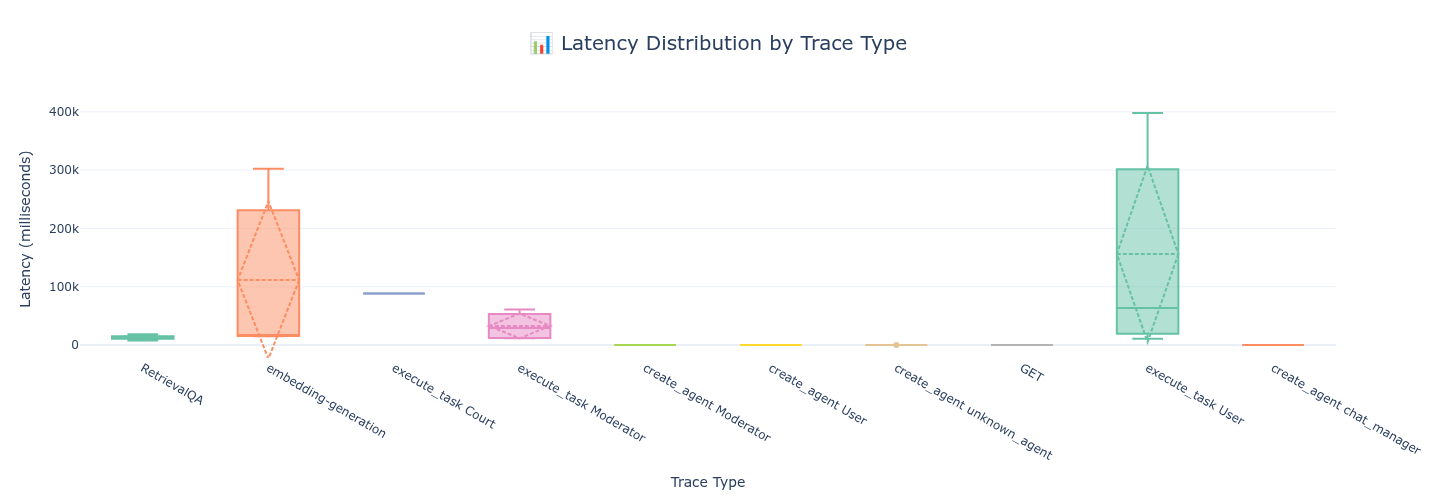

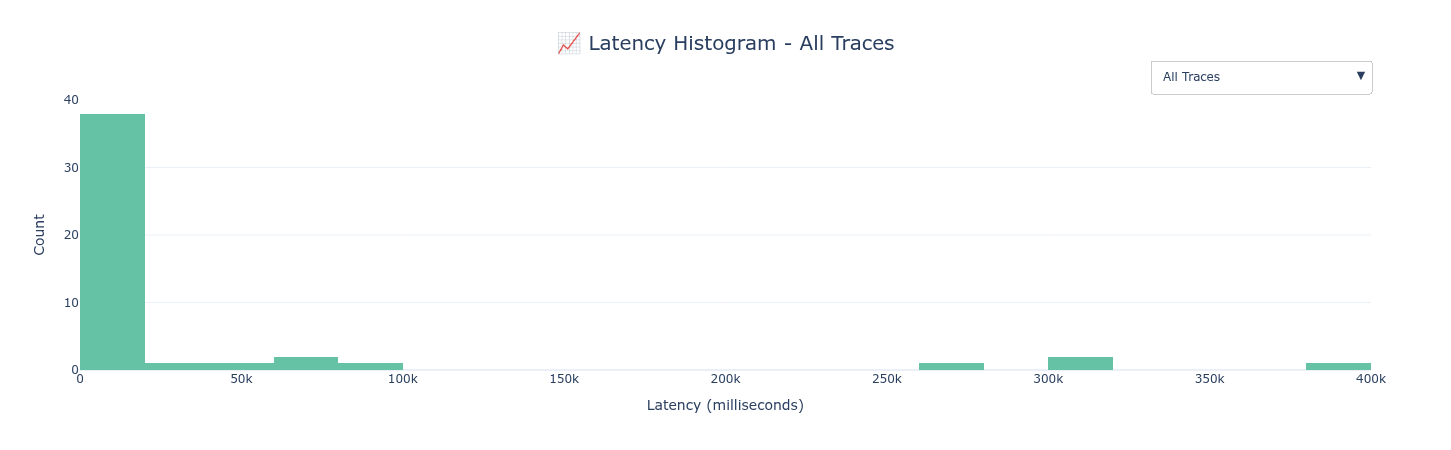

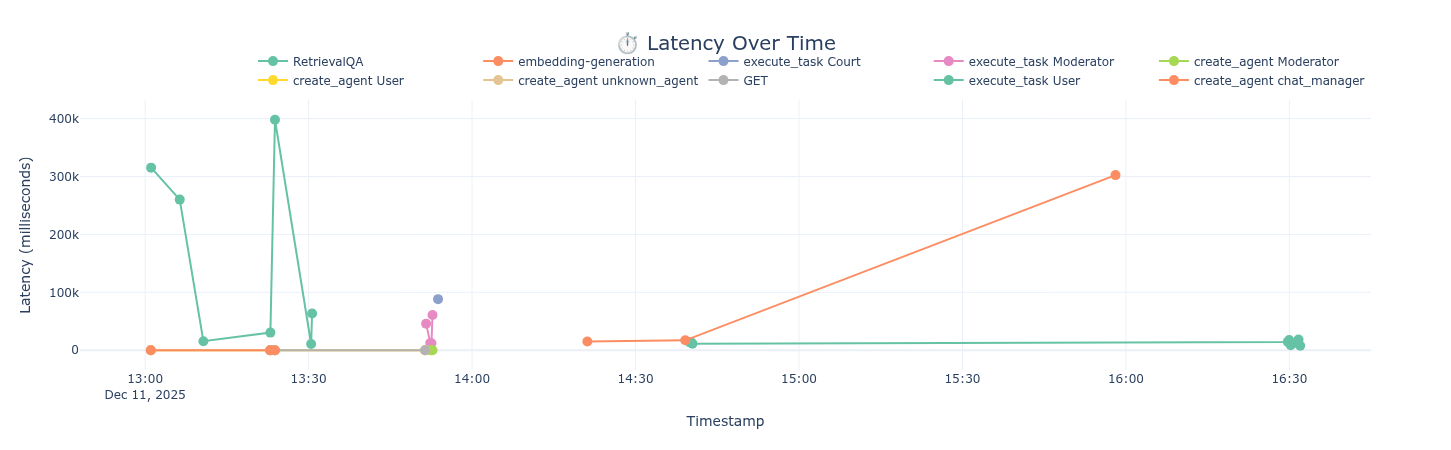


📈 PERFORMANCE SUMMARY

🔹 RetrievalQA
   Traces:  9
   Min:     7707 ms  (7.71 sec)
   Max:     18436 ms  (18.44 sec)
   Mean:    13160 ms  (13.16 sec)
   Median:  13640 ms  (13.64 sec)
   Std Dev: 3619 ms

🔹 embedding-generation
   Traces:  3
   Min:     14991 ms  (14.99 sec)
   Max:     302463 ms  (302.46 sec)
   Mean:    111532 ms  (111.53 sec)
   Median:  17143 ms  (17.14 sec)
   Std Dev: 165354 ms

🔹 execute_task Court
   Traces:  1
   Min:     88285 ms  (88.28 sec)
   Max:     88285 ms  (88.28 sec)
   Mean:    88285 ms  (88.28 sec)
   Median:  88285 ms  (88.28 sec)
   Std Dev: nan ms

🔹 execute_task Moderator
   Traces:  4
   Min:     11950 ms  (11.95 sec)
   Max:     60878 ms  (60.88 sec)
   Mean:    32841 ms  (32.84 sec)
   Median:  29268 ms  (29.27 sec)
   Std Dev: 24513 ms

🔹 create_agent Moderator
   Traces:  3
   Min:     1 ms  (0.00 sec)
   Max:     1 ms  (0.00 sec)
   Mean:    1 ms  (0.00 sec)
   Median:  1 ms  (0.00 sec)
   Std Dev: 0 ms

🔹 create_agent User
   Traces:  

In [8]:
# 📊 Create interactive visualizations to explore RAG pipeline performance
# Educational Goal: Show how to properly analyze performance metrics by trace type

if not df.empty and df['latency_ms'].notna().any():
    import plotly.graph_objects as go
    import plotly.express as px
    
    # Filter out traces without latency data
    df_with_latency = df[df['latency_ms'].notna()].copy()
    
    # Define a clean, colorblind-friendly palette
    colors = px.colors.qualitative.Set2
    
    # ═══════════════════════════════════════════════════════════════════════
    # VISUALIZATION 1: Box Plot - Latency Distribution by Trace Type
    # ═══════════════════════════════════════════════════════════════════════
    # Why: Shows that different operations have VASTLY different performance profiles
    # Key Learning: Never mix metrics from different operation types!
    
    fig1 = go.Figure()
    
    for i, trace_type in enumerate(df_with_latency['name'].unique()):
        trace_latencies = df_with_latency[df_with_latency['name'] == trace_type]['latency_ms']
        fig1.add_trace(go.Box(
            y=trace_latencies,
            name=trace_type,
            marker_color=colors[i % len(colors)],
            boxmean='sd',  # Show mean and std deviation
            hovertemplate="<b>%{fullData.name}</b><br>Latency: %{y:.0f} ms<extra></extra>"
        ))
    
    fig1.update_layout(
        title={
            'text': "📊 Latency Distribution by Trace Type",
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        },
        yaxis_title="Latency (milliseconds)",
        xaxis_title="Trace Type",
        template="plotly_white",
        height=500,
        showlegend=False,
        hovermode='closest'
    )
    
    fig1.show()
    
    # ═══════════════════════════════════════════════════════════════════════
    # VISUALIZATION 2: Interactive Histogram with Dropdown Filter
    # ═══════════════════════════════════════════════════════════════════════
    # Why: Allows exploring each trace type's distribution independently
    # Key Learning: RetrievalQA (8-13s) vs embedding-generation (1-2s) are different operations
    
    fig2 = go.Figure()
    
    # Add histogram for all traces (problematic - shows mixed distributions!)
    fig2.add_trace(go.Histogram(
        x=df_with_latency['latency_ms'],
        name='All Traces',
        nbinsx=20,
        visible=True,
        marker_color=colors[0],
        hovertemplate="Latency: %{x:.0f} ms<br>Count: %{y}<extra></extra>"
    ))
    
    # Add histogram for each trace type (proper segmentation)
    for i, trace_type in enumerate(df_with_latency['name'].unique()):
        trace_latencies = df_with_latency[df_with_latency['name'] == trace_type]['latency_ms']
        fig2.add_trace(go.Histogram(
            x=trace_latencies,
            name=trace_type,
            nbinsx=15,
            visible=False,
            marker_color=colors[i % len(colors)],
            hovertemplate=f"<b>{trace_type}</b><br>Latency: %{{x:.0f}} ms<br>Count: %{{y}}<extra></extra>"
        ))
    
    # Create dropdown menu for filtering
    buttons = [dict(
        label='All Traces',
        method='update',
        args=[{'visible': [True] + [False] * len(df_with_latency['name'].unique())},
              {'title': '📈 Latency Histogram - All Traces'}]
    )]
    
    for i, trace_type in enumerate(df_with_latency['name'].unique()):
        visible = [False] * (len(df_with_latency['name'].unique()) + 1)
        visible[i + 1] = True
        buttons.append(dict(
            label=trace_type,
            method='update',
            args=[{'visible': visible},
                  {'title': f'📈 Latency Histogram - {trace_type}'}]
        ))
    
    fig2.update_layout(
        title={
            'text': '📈 Latency Histogram - All Traces',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        },
        xaxis_title='Latency (milliseconds)',
        yaxis_title='Count',
        template="plotly_white",
        updatemenus=[dict(
            active=0,
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.0,
            xanchor="right",
            y=1.15,
            yanchor="top",
            bgcolor="white",
            bordercolor="#ccc",
            borderwidth=1
        )],
        height=450
    )
    
    fig2.show()
    
    # ═══════════════════════════════════════════════════════════════════════
    # VISUALIZATION 3: Timeline - Latency Over Time
    # ═══════════════════════════════════════════════════════════════════════
    # Why: Detect performance degradation or improvements over time
    # Key Learning: Watch for trends, spikes, or degradation patterns
    
    fig3 = go.Figure()
    
    for i, trace_type in enumerate(df_with_latency['name'].unique()):
        trace_df = df_with_latency[df_with_latency['name'] == trace_type]
        fig3.add_trace(go.Scatter(
            x=trace_df['timestamp'],
            y=trace_df['latency_ms'],
            mode='markers+lines',
            name=trace_type,
            marker=dict(size=10, color=colors[i % len(colors)]),
            line=dict(width=2, color=colors[i % len(colors)]),
            hovertemplate="<b>%{fullData.name}</b><br>Time: %{x}<br>Latency: %{y:.0f} ms<extra></extra>"
        ))
    
    fig3.update_layout(
        title={
            'text': "⏱️ Latency Over Time",
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        },
        xaxis_title='Timestamp',
        yaxis_title='Latency (milliseconds)',
        template="plotly_white",
        height=450,
        hovermode='closest',
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )
    
    fig3.show()
    
    # ═══════════════════════════════════════════════════════════════════════
    # SUMMARY STATISTICS TABLE
    # ═══════════════════════════════════════════════════════════════════════
    # Educational: Show statistics PER trace type (not mixed!)
    
    print("\n" + "="*80)
    print("📈 PERFORMANCE SUMMARY")
    print("="*80)
    
    for trace_type in df_with_latency['name'].unique():
        latencies = df_with_latency[df_with_latency['name'] == trace_type]['latency_ms']
        if len(latencies) > 0:
            print(f"\n🔹 {trace_type}")
            print(f"   Traces:  {len(latencies)}")
            print(f"   Min:     {latencies.min():.0f} ms  ({latencies.min()/1000:.2f} sec)")
            print(f"   Max:     {latencies.max():.0f} ms  ({latencies.max()/1000:.2f} sec)")
            print(f"   Mean:    {latencies.mean():.0f} ms  ({latencies.mean()/1000:.2f} sec)")
            print(f"   Median:  {latencies.median():.0f} ms  ({latencies.median()/1000:.2f} sec)")
            print(f"   Std Dev: {latencies.std():.0f} ms")
    
    print("\n" + "="*80)
    print("\n💡 Key Takeaway: RetrievalQA (~11s) is much slower than embedding-generation (~1.7s)")
    print("   because it involves vector search + LLM generation, while embeddings are just")
    print("   one model call. This is normal and expected!")
    print("\n" + "="*80)
    
    success(f"View detailed traces at {LANGFUSE_HOST}")
else:
    info("No trace data available for visualization. Run the RAG queries first!")

---
## 9. Papers Indexed (Reference for Notebook 03)

The following papers are now indexed in Qdrant and available for the multi-agent system in notebook 03.

In [9]:
# Display all indexed papers for reference
from IPython.display import display, Markdown

papers_md = "| # | Title | Authors | Date | Paper ID |\n"
papers_md += "|---|-------|---------|------|----------|\n"

for i, paper in enumerate(papers, 1):
    title_short = paper['title'][:60] + "..." if len(paper['title']) > 60 else paper['title']
    authors_short = paper['authors'][:40] + "..." if len(paper['authors']) > 40 else paper['authors']
    papers_md += f"| {i} | {title_short} | {authors_short} | {paper['published']} | `{paper['paper_id']}` |\n"

display(Markdown(papers_md))
print(f"\nTotal: {len(papers)} papers indexed in Qdrant collection '{collection_name}'")

| # | Title | Authors | Date | Paper ID |
|---|-------|---------|------|----------|
| 1 | Adaptive Rank Allocation for Federated Parameter-Efficient F... | Fei Wu, Jia Hu, Geyong Min, Shiqiang Wan... | 2025-01-24 | `2501.14406v3` |
| 2 | ARD-LoRA: Dynamic Rank Allocation for Parameter-Efficient Fi... | Haseeb Ullah Khan Shinwari, Muhammad Usa... | 2025-06-23 | `2506.18267v1` |
| 3 | ARA: Adaptive Rank Allocation for Efficient Large Language M... | Lin Xv, Jingsheng Gao, Xian Gao, Ting Li... | 2025-10-22 | `2510.19389v1` |
| 4 | HyperAdaLoRA: Accelerating LoRA Rank Allocation During Train... | Hao Zhang, Zhenjia Li, Runfeng Bao, Yifa... | 2025-10-03 | `2510.02630v1` |
| 5 | Adaptive Rank Allocation: Speeding Up Modern Transformers wi... | Roberto Garcia, Jerry Liu, Daniel Sorvis... | 2025-03-23 | `2503.18216v2` |
| 6 | AdaLoRA: Adaptive Budget Allocation for Parameter-Efficient ... | Qingru Zhang, Minshuo Chen, Alexander Bu... | 2023-03-18 | `2303.10512v2` |
| 7 | Dynamic Adaptive Rank Space Exploration for Efficient Sentim... | Hongcheng Ding, Fuzhen Hu, Ruiting Deng,... | 2024-10-22 | `2410.16589v2` |
| 8 | Beyond Low-Rank Tuning: Model Prior-Guided Rank Allocation f... | Chuyan Zhang, Kefan Wang, Yun Gu | 2025-06-30 | `2507.00327v1` |
| 9 | A Sampling-Based Adaptive Rank Approach to the Wigner-Poisso... | Andrew Christlieb, Sining Gong, Jing-Mei... | 2025-06-26 | `2506.21314v1` |
| 10 | Layer-wise dynamic rank for compressing large language model... | Zhendong Mi, Bian Sun, Grace Li Zhang, S... | 2025-09-30 | `2509.25622v2` |
| 11 | High-order Adaptive Rank Integrators for Multi-scale Linear ... | William A. Sands, Wei Guo, Jing-Mei Qiu,... | 2024-06-27 | `2406.19479v3` |
| 12 | Factor Fitting, Rank Allocation, and Partitioning in Multile... | Tetiana Parshakova, Trevor Hastie, Eric ... | 2023-10-30 | `2310.19214v2` |
| 13 | RankAdaptor: Hierarchical Rank Allocation for Efficient Fine... | Changhai Zhou, Shijie Han, Lining Yang, ... | 2024-06-22 | `2406.15734v2` |
| 14 | Efficient Dynamic Rank Aggregation | Morteza Alimi, Hourie Mehrabiun, Alireza... | 2025-09-02 | `2509.02885v1` |
| 15 | Dynamic Rank Adaptation for Vision-Language Models | Jiahui Wang, Qin Xu, Bo Jiang, Bin Luo | 2025-07-08 | `2507.05668v1` |
| 16 | A Semi-Lagrangian Adaptive Rank (SLAR) Method for High-Dimen... | Nanyi Zheng, William A. Sands, Daniel Ha... | 2025-10-28 | `2510.24861v1` |
| 17 | A Semi-Lagrangian Adaptive-Rank (SLAR) Method for Linear Adv... | Nanyi Zheng, Daniel Hayes, Andrew Christ... | 2024-11-27 | `2411.17963v1` |
| 18 | Dynamic Rank Adjustment in Diffusion Policies for Efficient ... | Xiatao Sun, Shuo Yang, Yinxing Chen, Fra... | 2025-02-06 | `2502.03822v3` |
| 19 | Dynamic Rank Adjustment for Accurate and Efficient Neural Ne... | Hyuntak Shin, Aecheon Jung, Sungeun Hong... | 2025-08-12 | `2508.08625v3` |
| 20 | Krylov-based Adaptive-Rank Implicit Time Integrators for Sti... | Hamad El Kahza, William Taitano, Jing-Me... | 2024-04-03 | `2404.03119v1` |
| 21 | Adaptive Rank, Reduced Forgetting: Knowledge Retention in Co... | Haodong Lu, Chongyang Zhao, Jason Xue, L... | 2024-12-01 | `2412.01004v6` |
| 22 | Structured Learning of Two-Level Dynamic Rankings | Karthik Raman, Thorsten Joachims, Pannag... | 2011-08-13 | `1108.2754v1` |
| 23 | Sylvester-Preconditioned Adaptive-Rank Implicit Time Integra... | Hamad El Kahza, Jing-Mei Qiu, Luis Chaco... | 2024-10-25 | `2410.19662v3` |
| 24 | An Adaptive-rank Approach with Greedy Sampling for Multi-sca... | William A. Sands, Jing-Mei Qiu, Daniel H... | 2025-05-22 | `2505.17191v2` |
| 25 | A model for efficient dynamical ranking in networks | Andrea Della Vecchia, Kibidi Neocosmos, ... | 2023-07-25 | `2307.13544v2` |
| 26 | Efficient Storage of Fine-Tuned Models via Low-Rank Approxim... | Simo Ryu, Seunghyun Seo, Jaejun Yoo | 2023-05-28 | `2305.18425v1` |
| 27 | Unifying Instance and Panoptic Segmentation with Dynamic Ran... | Hao Chen, Chunhua Shen, Zhi Tian | 2020-11-19 | `2011.09796v1` |
| 28 | AROMA: Autonomous Rank-one Matrix Adaptation | Hao Nan Sheng, Zhi-yong Wang, Mingrui Ya... | 2025-04-06 | `2504.05343v2` |
| 29 | Preference-Based Dynamic Ranking Structure Recognition | Nan Lu, Jian Shi, Xin-Yu Tian | 2025-09-29 | `2509.24493v2` |
| 30 | Adaptive Ranking Based Constraint Handling for Explicitly Co... | Naoki Sakamoto, Youhei Akimoto | 2018-11-02 | `1811.00764v3` |
| 31 | Adaptive Ranking-based Sample Selection for Weakly Supervise... | Linxin Song, Jieyu Zhang, Tianxiang Yang... | 2022-10-06 | `2210.03092v2` |
| 32 | TARA Test-by-Adaptive-Ranks for Quantum Anomaly Detection wi... | Davut Emre Tasar, Ceren Ocal Tasar | 2025-12-03 | `2512.04016v1` |
| 33 | ElaLoRA: Elastic & Learnable Low-Rank Adaptation for Efficie... | Huandong Chang, Zicheng Ma, Mingyuan Ma,... | 2025-03-31 | `2504.00254v1` |
| 34 | Efficient Fine-Tuning of Quantized Models via Adaptive Rank ... | Changhai Zhou, Shijie Han, Shiyang Zhang... | 2025-05-02 | `2505.03802v3` |
| 35 | Optimizing Gross Merchandise Volume via DNN-MAB Dynamic Rank... | Yan Yan, Wentao Guo, Meng Zhao, Jinghe H... | 2017-08-14 | `1708.03993v1` |
| 36 | Sparsely Shared LoRA on Whisper for Child Speech Recognition | Wei Liu, Ying Qin, Zhiyuan Peng, Tan Lee | 2023-09-21 | `2309.11756v2` |
| 37 | Analyzing and Forecasting Success in the Men's Ice Hockey Wo... | Vladimír Holý | 2024-09-09 | `2409.05714v2` |
| 38 | TsqLoRA: Towards Sensitivity and Quality Low-Rank Adaptation... | Yu Chen, Yifei Han, Long Zhang, Yue Du, ... | 2025-09-23 | `2509.18585v1` |
| 39 | A Bayesian Interpretation of Adaptive Low-Rank Adaptation | Haolin Chen, Philip N. Garner | 2024-09-16 | `2409.10673v2` |
| 40 | FoRA: Low-Rank Adaptation Model beyond Multimodal Siamese Ne... | Weiying Xie, Yusi Zhang, Tianlin Hui, Ji... | 2024-07-23 | `2407.16129v1` |
| 41 | Dynamic Context-oriented Decomposition for Task-aware Low-ra... | Yibo Yang, Sihao Liu, Chuan Rao, Bang An... | 2025-06-16 | `2506.13187v1` |
| 42 | Parameter Efficient Continual Learning with Dynamic Low-Rank... | Prashant Shivaram Bhat, Shakib Yazdani, ... | 2025-05-17 | `2505.11998v2` |
| 43 | Full-Rank No More: Low-Rank Weight Training for Modern Speec... | Adriana Fernandez-Lopez, Shiwei Liu, Lu ... | 2024-10-10 | `2410.07771v1` |
| 44 | GeoLoRA: Geometric integration for parameter efficient fine-... | Steffen Schotthöfer, Emanuele Zangrando,... | 2024-10-24 | `2410.18720v1` |
| 45 | PrunedLoRA: Robust Gradient-Based structured pruning for Low... | Xin Yu, Cong Xie, Ziyu Zhao, Tiantian Fa... | 2025-09-30 | `2510.00192v2` |
| 46 | L1RA: Dynamic Rank Assignment in LoRA Fine-Tuning | Raul Singh, Nicolo Brunello, Vincenzo Sc... | 2025-09-05 | `2509.04884v1` |
| 47 | Singular Value Decomposition on Kronecker Adaptation for Lar... | Yee Hin Chong, Peng Qu | 2025-06-18 | `2506.15251v1` |
| 48 | Fast and Continual Knowledge Graph Embedding via Incremental... | Jiajun Liu, Wenjun Ke, Peng Wang, Jiahao... | 2024-07-08 | `2407.05705v1` |
| 49 | LaMDA: Large Model Fine-Tuning via Spectrally Decomposed Low... | Seyedarmin Azizi, Souvik Kundu, Massoud ... | 2024-06-18 | `2406.12832v1` |
| 50 | Lightweight Model Editing for LLMs to Correct Deprecated API... | Guancheng Lin, Xiao Yu, Jacky Keung, Xin... | 2025-11-26 | `2511.21022v1` |
| 51 | PLoRA: Efficient LoRA Hyperparameter Tuning for Large Models | Minghao Yan, Zhuang Wang, Zhen Jia, Shiv... | 2025-08-04 | `2508.02932v1` |
| 52 | A Note on LoRA | Vlad Fomenko, Han Yu, Jongho Lee, Stanle... | 2024-04-07 | `2404.05086v1` |
| 53 | LangVision-LoRA-NAS: Neural Architecture Search for Variable... | Krishna Teja Chitty-Venkata, Murali Eman... | 2025-08-17 | `2508.12512v1` |
| 54 | Low-rank variational dropout: Uncertainty and rank selection... | Cooper Doyle | 2025-06-28 | `2506.22809v2` |
| 55 | MTL-LoRA: Low-Rank Adaptation for Multi-Task Learning | Yaming Yang, Dilxat Muhtar, Yelong Shen,... | 2024-10-12 | `2410.09437v3` |
| 56 | Revisiting LoRA through the Lens of Parameter Redundancy: Sp... | Jiashun Cheng, Aochuan Chen, Nuo Chen, Z... | 2025-06-20 | `2506.16787v1` |
| 57 | LoRA meets Riemannion: Muon Optimizer for Parametrization-in... | Vladimir Bogachev, Vladimir Aletov, Alex... | 2025-07-16 | `2507.12142v2` |
| 58 | FedEx-LoRA: Exact Aggregation for Federated and Efficient Fi... | Raghav Singhal, Kaustubh Ponkshe, Pranee... | 2024-10-12 | `2410.09432v4` |
| 59 | LoRATK: LoRA Once, Backdoor Everywhere in the Share-and-Play... | Hongyi Liu, Shaochen Zhong, Xintong Sun,... | 2024-02-29 | `2403.00108v2` |
| 60 | Bernoulli-LoRA: A Theoretical Framework for Randomized Low-R... | Igor Sokolov, Abdurakhmon Sadiev, Yury D... | 2025-08-05 | `2508.03820v1` |
| 61 | LD-MoLE: Learnable Dynamic Routing for Mixture of LoRA Exper... | Yuan Zhuang, Yi Shen, Yuexin Bian, Qing ... | 2025-09-30 | `2509.25684v1` |
| 62 | Efficient Split Federated Learning for Large Language Models... | Kai Zhao, Zhaohui Yang, Ye Hu, Mingzhe C... | 2025-04-20 | `2504.14667v2` |
| 63 | GoRA: Gradient-driven Adaptive Low Rank Adaptation | Haonan He, Peng Ye, Yuchen Ren, Yuan Yua... | 2025-02-13 | `2502.12171v3` |
| 64 | Extremal properties for dissections of convex 3-polytopes | Jesús A. De Loera, Francisco Santos, Fum... | 2000-12-18 | `0012169v1` |
| 65 | The Primacy of Magnitude in Low-Rank Adaptation | Zicheng Zhang, Haoran Li, Yifeng Zhang, ... | 2025-07-09 | `2507.06558v1` |
| 66 | A second-order-like optimizer with adaptive gradient scaling... | Jérôme Bolte, Ryan Boustany, Edouard Pau... | 2024-10-08 | `2410.05871v2` |
| 67 | GLAD: Generalizable Tuning for Vision-Language Models | Yuqi Peng, Pengfei Wang, Jianzhuang Liu,... | 2025-07-17 | `2507.13089v1` |
| 68 | BeamLoRA: Beam-Constraint Low-Rank Adaptation | Naibin Gu, Zhenyu Zhang, Xiyu Liu, Peng ... | 2025-02-19 | `2502.13604v2` |
| 69 | MSPLoRA: A Multi-Scale Pyramid Low-Rank Adaptation for Effic... | Jiancheng Zhao, Xingda Yu, Zhen Yang | 2025-03-27 | `2503.21838v1` |
| 70 | FouRA: Fourier Low Rank Adaptation | Shubhankar Borse, Shreya Kadambi, Nilesh... | 2024-06-13 | `2406.08798v1` |
| 71 | ConsNoTrainLoRA: Data-driven Weight Initialization of Low-ra... | Debasmit Das, Hyoungwoo Park, Munawar Ha... | 2025-07-09 | `2507.08044v1` |
| 72 | Fine-tuning LLMs with variational Bayesian last layer for hi... | Haotian Xiang, Jinwen Xu, Qin Lu | 2025-10-01 | `2510.01471v2` |
| 73 | SEAL: Entangled White-box Watermarks on Low-Rank Adaptation | Giyeong Oh, Saejin Kim, Woohyun Cho, San... | 2025-01-16 | `2501.09284v2` |
| 74 | Ehrhart polynomials of matroid polytopes and polymatroids | Jesús A. De Loera, David C. Haws, Matthi... | 2007-10-23 | `0710.4346v1` |
| 75 | TASO: Task-Aligned Sparse Optimization for Parameter-Efficie... | Daiye Miao, Yufang Liu, Jie Wang, Changz... | 2025-09-22 | `2509.17688v1` |
| 76 | ETHER: Efficient Finetuning of Large-Scale Models with Hyper... | Massimo Bini, Karsten Roth, Zeynep Akata... | 2024-05-30 | `2405.20271v2` |
| 77 | FedP$^2$EFT: Federated Learning to Personalize PEFT for Mult... | Royson Lee, Minyoung Kim, Fady Rezk, Rui... | 2025-02-05 | `2502.04387v3` |
| 78 | GraLoRA: Granular Low-Rank Adaptation for Parameter-Efficien... | Yeonjoon Jung, Daehyun Ahn, Hyungjun Kim... | 2025-05-26 | `2505.20355v1` |
| 79 | Origin of third harmonic generation in plasmonic nanoantenna... | Antonino Calà Lesina, Pierre Berini, Lor... | 2016-10-25 | `1610.08025v1` |
| 80 | StereoAdapter: Adapting Stereo Depth Estimation to Underwate... | Zhengri Wu, Yiran Wang, Yu Wen, Zeyu Zha... | 2025-09-19 | `2509.16415v1` |
| 81 | Optuna vs Code Llama: Are LLMs a New Paradigm for Hyperparam... | Roman Kochnev, Arash Torabi Goodarzi, Zo... | 2025-04-08 | `2504.06006v4` |
| 82 | FLoRIST: Singular Value Thresholding for Efficient and Accur... | Hariharan Ramesh, Jyotikrishna Dass | 2025-06-10 | `2506.09199v1` |
| 83 | Block Circulant Adapter for Large Language Models | Xinyu Ding, Meiqi Wang, Siyu Liao, Zhong... | 2025-05-01 | `2505.00582v2` |
| 84 | SARA: Singular-Value Based Adaptive Low-Rank Adaption | Jihao Gu, Shuai Chen, Zelin Wang, Yibo Z... | 2024-08-06 | `2408.03290v1` |
| 85 | Alternative Chirp Spread Spectrum Techniques for LPWANs | Ivo Bizon Franco de Almeida, Marwa Chafi... | 2021-02-18 | `2102.09250v2` |
| 86 | Monotone Paths on Cross-Polytopes | Alexander Black, Jesús De Loera | 2021-02-02 | `2102.01237v2` |
| 87 | Aggregate, Decompose, and Fine-Tune: A Simple Yet Effective ... | Dongping Chen | 2023-11-12 | `2311.06749v1` |
| 88 | KaSA: Knowledge-Aware Singular-Value Adaptation of Large Lan... | Fan Wang, Juyong Jiang, Chansung Park, S... | 2024-12-08 | `2412.06071v2` |
| 89 | Random Masking Finds Winning Tickets for Parameter Efficient... | Jing Xu, Jingzhao Zhang | 2024-05-04 | `2405.02596v1` |
| 90 | The Ultimate Guide to Fine-Tuning LLMs from Basics to Breakt... | Venkatesh Balavadhani Parthasarathy, Aht... | 2024-08-23 | `2408.13296v3` |
| 91 | Towards Robust and Efficient Federated Low-Rank Adaptation w... | Jabin Koo, Minwoo Jang, Jungseul Ok | 2024-10-30 | `2410.22815v2` |
| 92 | ControlNeXt: Powerful and Efficient Control for Image and Vi... | Bohao Peng, Jian Wang, Yuechen Zhang, We... | 2024-08-12 | `2408.06070v3` |
| 93 | Gen-AI Police Sketches with Stable Diffusion | Nicholas Fidalgo, Aaron Contreras, Kathe... | 2025-07-24 | `2507.18667v1` |
| 94 | ESSA: Evolutionary Strategies for Scalable Alignment | Daria Korotyshova, Boris Shaposhnikov, A... | 2025-07-06 | `2507.04453v2` |
| 95 | MLorc: Momentum Low-rank Compression for Memory Efficient La... | Wei Shen, Zhang Yaxiang, Minhui Huang, M... | 2025-06-02 | `2506.01897v3` |
| 96 | DiffusionLight: Light Probes for Free by Painting a Chrome B... | Pakkapon Phongthawee, Worameth Chinchuth... | 2023-12-14 | `2312.09168v3` |
| 97 | TriAdaptLoRA: Brain-Inspired Triangular Adaptive Low-Rank Ad... | Yao Liang, Yuwei Wang, Yi Zeng | 2025-01-14 | `2501.08008v1` |
| 98 | LoLDU: Low-Rank Adaptation via Lower-Diag-Upper Decompositio... | Yiming Shi, Jiwei Wei, Yujia Wu, Ran Ran... | 2024-10-17 | `2410.13618v1` |
| 99 | MELoRA: Mini-Ensemble Low-Rank Adapters for Parameter-Effici... | Pengjie Ren, Chengshun Shi, Shiguang Wu,... | 2024-02-27 | `2402.17263v3` |
| 100 | VB-LoRA: Extreme Parameter Efficient Fine-Tuning with Vector... | Yang Li, Shaobo Han, Shihao Ji | 2024-05-24 | `2405.15179v3` |
| 101 | LoRA-FAIR: Federated LoRA Fine-Tuning with Aggregation and I... | Jieming Bian, Lei Wang, Letian Zhang, Ji... | 2024-11-22 | `2411.14961v3` |
| 102 | One-for-All: Generalized LoRA for Parameter-Efficient Fine-t... | Arnav Chavan, Zhuang Liu, Deepak Gupta, ... | 2023-06-13 | `2306.07967v2` |
| 103 | OPLoRA: Orthogonal Projection LoRA Prevents Catastrophic For... | Yifeng Xiong, Xiaohui Xie | 2025-10-14 | `2510.13003v2` |
| 104 | Flat-LoRA: Low-Rank Adaptation over a Flat Loss Landscape | Tao Li, Zhengbao He, Yujun Li, Yasheng W... | 2024-09-22 | `2409.14396v2` |
| 105 | PC-LoRA: Low-Rank Adaptation for Progressive Model Compressi... | Injoon Hwang, Haewon Park, Youngwan Lee,... | 2024-06-13 | `2406.09117v1` |
| 106 | TT-LoRA MoE: Unifying Parameter-Efficient Fine-Tuning and Sp... | Pradip Kunwar, Minh N. Vu, Maanak Gupta,... | 2025-04-29 | `2504.21190v1` |
| 107 | MLAE: Masked LoRA Experts for Visual Parameter-Efficient Fin... | Junjie Wang, Guangjing Yang, Wentao Chen... | 2024-05-29 | `2405.18897v2` |
| 108 | LoRA-C: Parameter-Efficient Fine-Tuning of Robust CNN for Io... | Chuntao Ding, Xu Cao, Jianhang Xie, Linl... | 2024-10-22 | `2410.16954v2` |
| 109 | Randomized Asymmetric Chain of LoRA: The First Meaningful Th... | Grigory Malinovsky, Umberto Michieli, Ha... | 2024-10-10 | `2410.08305v1` |
| 110 | LoRA-Pro: Are Low-Rank Adapters Properly Optimized? | Zhengbo Wang, Jian Liang, Ran He, Zilei ... | 2024-07-25 | `2407.18242v3` |
| 111 | C-LoRA: Contextual Low-Rank Adaptation for Uncertainty Estim... | Amir Hossein Rahmati, Sanket Jantre, Wei... | 2025-05-23 | `2505.17773v3` |
| 112 | NAS-LoRA: Empowering Parameter-Efficient Fine-Tuning for Vis... | Renqi Chen, Haoyang Su, Shixiang Tang | 2025-12-03 | `2512.03499v1` |
| 113 | C-LoRA: Continual Low-Rank Adaptation for Pre-trained Models | Xin Zhang, Liang Bai, Xian Yang, Jiye Li... | 2025-02-25 | `2502.17920v1` |
| 114 | LoRA-GA: Low-Rank Adaptation with Gradient Approximation | Shaowen Wang, Linxi Yu, Jian Li | 2024-07-06 | `2407.05000v2` |
| 115 | BA-LoRA: Bias-Alleviating Low-Rank Adaptation to Mitigate Ca... | Yupeng Chang, Yi Chang, Yuan Wu | 2024-08-08 | `2408.04556v6` |
| 116 | QR-LoRA: QR-Based Low-Rank Adaptation for Efficient Fine-Tun... | Jessica Liang, Anirudh Bharadwaj | 2025-08-29 | `2508.21810v1` |
| 117 | Quantum-PEFT: Ultra parameter-efficient fine-tuning | Toshiaki Koike-Akino, Francesco Tonin, Y... | 2025-03-07 | `2503.05431v1` |
| 118 | AFLoRA: Adaptive Freezing of Low Rank Adaptation in Paramete... | Zeyu Liu, Souvik Kundu, Anni Li, Junrui ... | 2024-03-20 | `2403.13269v3` |
| 119 | LoRA-Null: Low-Rank Adaptation via Null Space for Large Lang... | Pengwei Tang, Yong Liu, Dongjie Zhang, X... | 2025-03-04 | `2503.02659v1` |
| 120 | DropLoRA: Sparse Low-Rank Adaptation for Parameter-Efficient... | Haojie Zhang | 2025-08-24 | `2508.17337v1` |
| 121 | PLoP: Precise LoRA Placement for Efficient Finetuning of Lar... | Soufiane Hayou, Nikhil Ghosh, Bin Yu | 2025-06-25 | `2506.20629v1` |
| 122 | LoRA-MGPO: Mitigating Double Descent in Low-Rank Adaptation ... | Yupeng Chang, Chenlu Guo, Yi Chang, Yuan... | 2025-02-20 | `2502.14538v3` |
| 123 | DoRA: Enhancing Parameter-Efficient Fine-Tuning with Dynamic... | Yulong Mao, Kaiyu Huang, Changhao Guan, ... | 2024-05-27 | `2405.17357v3` |
| 124 | Parameter-Efficient Fine-Tuning Design Spaces | Jiaao Chen, Aston Zhang, Xingjian Shi, M... | 2023-01-04 | `2301.01821v1` |
| 125 | BoRA: Bi-dimensional Weight-Decomposed Low-Rank Adaptation | Qiushi Wang, Yuchen Fan, Junwei Bao, Hon... | 2024-12-09 | `2412.06441v1` |
| 126 | RaSA: Rank-Sharing Low-Rank Adaptation | Zhiwei He, Zhaopeng Tu, Xing Wang, Xingy... | 2025-03-16 | `2503.12576v1` |
| 127 | The Expressive Power of Low-Rank Adaptation | Yuchen Zeng, Kangwook Lee | 2023-10-26 | `2310.17513v3` |
| 128 | LoRA: Low-Rank Adaptation of Large Language Models | Edward J. Hu, Yelong Shen, Phillip Walli... | 2021-06-17 | `2106.09685v2` |
| 129 | LoRA-FA: Memory-efficient Low-rank Adaptation for Large Lang... | Longteng Zhang, Lin Zhang, Shaohuai Shi,... | 2023-08-07 | `2308.03303v1` |
| 130 | Implicit Style-Content Separation using B-LoRA | Yarden Frenkel, Yael Vinker, Ariel Shami... | 2024-03-21 | `2403.14572v2` |
| 131 | LoRA Done RITE: Robust Invariant Transformation Equilibratio... | Jui-Nan Yen, Si Si, Zhao Meng, Felix Yu,... | 2024-10-27 | `2410.20625v2` |
| 132 | Less is More: Resource-Efficient Low-Rank Adaptation | Chunlin Tian, Xuyang Wei, Huanrong Liu, ... | 2025-11-30 | `2512.00878v1` |
| 133 | MoRA: High-Rank Updating for Parameter-Efficient Fine-Tuning | Ting Jiang, Shaohan Huang, Shengyue Luo,... | 2024-05-20 | `2405.12130v1` |
| 134 | Bayesian-LoRA: LoRA based Parameter Efficient Fine-Tuning us... | Cristian Meo, Ksenia Sycheva, Anirudh Go... | 2024-06-18 | `2406.13046v3` |
| 135 | Computational Limits of Low-Rank Adaptation (LoRA) Fine-Tuni... | Jerry Yao-Chieh Hu, Maojiang Su, En-Jui ... | 2024-06-05 | `2406.03136v2` |
| 136 | HoRA: Cross-Head Low-Rank Adaptation with Joint Hypernetwork... | Nghiem T. Diep, Dung Le, Tuan Truong, Ta... | 2025-10-05 | `2510.04295v1` |
| 137 | CL-LoRA: Continual Low-Rank Adaptation for Rehearsal-Free Cl... | Jiangpeng He, Zhihao Duan, Fengqing Zhu | 2025-05-30 | `2505.24816v1` |
| 138 | ALoRA: Allocating Low-Rank Adaptation for Fine-tuning Large ... | Zequan Liu, Jiawen Lyn, Wei Zhu, Xing Ti... | 2024-03-24 | `2403.16187v2` |
| 139 | MoDE: Effective Multi-task Parameter Efficient Fine-Tuning w... | Lin Ning, Harsh Lara, Meiqi Guo, Abhinav... | 2024-08-02 | `2408.01505v1` |
| 140 | ABM-LoRA: Activation Boundary Matching for Fast Convergence ... | Dongha Lee, Jinhee Park, Minjun Kim, Jun... | 2025-11-24 | `2511.19145v3` |
| 141 | LoRA+: Efficient Low Rank Adaptation of Large Models | Soufiane Hayou, Nikhil Ghosh, Bin Yu | 2024-02-19 | `2402.12354v2` |
| 142 | NoRA: Nested Low-Rank Adaptation for Efficient Fine-Tuning L... | Cheng Lin, Lujun Li, Dezhi Li, Jie Zou, ... | 2024-08-18 | `2408.10280v2` |



Total: 142 papers indexed in Qdrant collection 'research_papers'
